# Load Data for CLustering
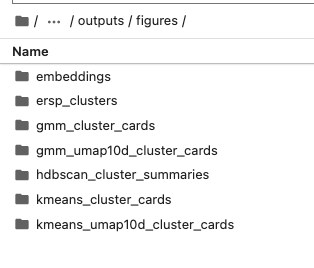
210_clustering.ipynb

With fs_ds≈1000 and nfft=256:

Number of rows F = nfft/2 + 1 = 129.

Row k (0…128) corresponds to center frequency
f_k = k × (fs_ds / nfft) ≈ k × 3.90625 Hz.

Examples:
k=0 → 0 Hz, k=13 → ~50.78 Hz, k=26 → ~101.56 Hz, … k=102 → ~398.44 Hz, k=128 → 500 Hz.
Your plots limit to fmax=400 Hz, but the matrix still includes rows up to 500 Hz.

Interpretation: a single A[f,t] is the trial-average ΔdB in a ~3.9 Hz-wide band centered at f_k, computed from a 128 ms Hann window, then time-normalized into the stim/post phases.

In [94]:
## 0. Config & imports
import os
from pathlib import Path
import datetime
import json

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt  # for optional plots (no seaborn)

# ---- Identity / tags ----
SCRIPT_NAME = "210_clustering_UMAP.ipynb"
ALGO_TAG = "clustering_UMAP10"
RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")  # e.g. 20251117_112233

# ---- Paths ----
ANALYSIS_ROOT = Path(r"\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora")

# Input: RAWONLY ERSP matrices
INPUT_DIR = ANALYSIS_ROOT / r"01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY"

# Output: clustering results & figures
CLUSTERING_OUTPUT_DIR  = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/kmeans"
FIGURES_EMBEDDINGS_DIR = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/embeddings"
FIGURES_ERSP_DIR       = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/ersp_clusters"
LOG_DIR                = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/logs"

for d in [CLUSTERING_OUTPUT_DIR, FIGURES_EMBEDDINGS_DIR, FIGURES_ERSP_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# WM electrodes for double check    
# ---- WM reference maps (unchanged data, compact helpers) ----
WHITE_MATTER_REFS_NUMS = {
    "PAT_3066": {"FIG":[6,5], "FOG":[15], "FOD":[12], "CAG":[11,10,9,8,7], "CAD":[8,6,5,3,2],
                 "IAG":[18,11,9,3,2], "IMG":[18,9,8,7,6,3], "AG":[3,2,1], "HAG":[1], "HPG":[7,2],
                 "PPG":[6,5,4,2], "TIG":[3], "AD":[8,6,4,3,2,1], "HAD":[3,2,1], "HPD":[2,1], "PPD":[6,5,4,3]},
    "PAT_3975": {"FOG":[15,10,8,3,1], "CPG":[10,6,5,4,3], "AG":[12], "HAG":[5,2,1], "PHG":[6,4],
                 "IAG":[8,6,4,3,2,1], "IMG":[13,12,11,6,3], "FOD":[14,13,12,11,9,6,5,3],
                 "CPD":[15,8,6,2], "AD":[7,4,3,2,1], "HAD":[3,2,1], "PHD":[11,7], "IAD":[10],
                 "IMD":[17,16,15,14,12,10,9,7]},
    "PAT_3415": {"IMG":[16,15,12,11,8,6,5,4,3,2], "IPG":[12,10,8,3,2,1], "HLG":[17,16,3,2]},
    "PAT_3965": {"ag":[3,4,5,6], "hpg":[8,9,10,11], "imd":[6,7,8,9,10,11,12]},
    "PAT_2868": {"POP":[3], "IDM":[4,1], "SMA":[2,1], "PPS":[3,2,1], "PRI":[3,2,1], "POM":[4,1],
                 "PPI":[2], "POI":[3,2,1]},
    "PAT_3455": {"AD":[2,1], "HAD":[2,1], "TOD":[6], "CPD":[12,11,10,9,6,5,2], "OPD":[5,4,3,2],
                 "PHD":[5], "OTD":[8], "TSP":[8,6,5,4], "IMD":[11,5,4,3], "IPD":[14,11]},
    "PAT_3390": {"IAG":[18,17,16,9,1], "CAG":[8,6,5,4,2], "CPG":[15,13,10,9,1], "HPG":[10,9,8],
                 "AG":[12,11], "HAG":[12,11,10,9], "FOG":[9,4,3,2,1]},
    "MicroEPI-B-01": {"pI_L":[8,9,10,11,12,13,14], "A_L":[4,5],"ITG_L":[6,9],"sSMG_L":[2,3,5,6],"IOG_L":[4,5,7],"LinG_L":[4,5]}
}


# ---- Data shape constants ----
N_TIME = 300
N_FREQ = 129

# --- Adjust these to match your ERSP pipeline ---
FREQ_MIN_HZ = 1      # e.g. lowest freq bin
FREQ_MAX_HZ = 500    # e.g. highest freq bin

TIME_MIN_PCT = 0     # start of window as % of trial
TIME_MAX_PCT = 100   # end of window as % of trial

# --- Derived axes used in all imshow() calls ---
FREQ_AXIS_HZ   = np.linspace(FREQ_MIN_HZ, FREQ_MAX_HZ, N_FREQ)
TIME_AXIS_PCT  = np.linspace(TIME_MIN_PCT, TIME_MAX_PCT, N_TIME)

print("FREQ_AXIS_HZ shape :", FREQ_AXIS_HZ.shape,  "min/max:", FREQ_AXIS_HZ[0], FREQ_AXIS_HZ[-1])
print("TIME_AXIS_PCT shape:", TIME_AXIS_PCT.shape, "min/max:", TIME_AXIS_PCT[0], TIME_AXIS_PCT[-1])

N_FEATURES = N_TIME * N_FREQ

# ---- Clustering parameters ----
# N_CLUSTERS = 13
RANDOM_STATE = 42

print("SCRIPT_NAME:", SCRIPT_NAME)
print("ALGO_TAG   :", ALGO_TAG)
print("RUN_ID     :", RUN_ID)
print("Input dir  :", INPUT_DIR)


## Auto-detect patient IDs from outputs/04_ersp_LM_RAWONLY

from pathlib import Path

# Patient folders = all directories inside INPUT_DIR
PATIENT_IDS = sorted([d.name for d in INPUT_DIR.iterdir() if d.is_dir()])

print("Detected patient folders:")
for p in PATIENT_IDS:
    print("  -", p)

print("\nTotal patients detected:", len(PATIENT_IDS))


FREQ_AXIS_HZ shape : (129,) min/max: 1.0 500.0
TIME_AXIS_PCT shape: (300,) min/max: 0.0 100.0
SCRIPT_NAME: 210_clustering_UMAP.ipynb
ALGO_TAG   : clustering_UMAP10
RUN_ID     : 20251208_152815
Input dir  : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY
Detected patient folders:
  - EL030
  - EL035
  - EL036
  - EL037
  - EL038
  - EL040
  - EL042
  - PAT_2868
  - PAT_3066
  - PAT_3301
  - PAT_3390
  - PAT_3415
  - PAT_3455
  - PAT_3780
  - PAT_3965
  - PAT_3975

Total patients detected: 16


In [95]:
## 2. Helper: parse electrode name from filename

def parse_electrode_from_filename(fname: str) -> str:
    """
    Example filenames:
        PAT_3301_picture_None_ERSP_AG2_TN.npy   -> electrode = 'AG2'
        EL035_reading_WM_ERSP_A_R10_TN.npy      -> electrode = 'A_R10'
        EL035_reading_WM_ERSP_Fp2_TN.npy        -> electrode = 'Fp2'
        EL030_audio_WM_ERSP_aH_L1_TN.npy        -> electrode = 'aH_L1'

    Assumes pattern: ..._ERSP_<electrode>_<suffix>.npy
    where <electrode> may contain underscores or dashes.
    """
    name = Path(fname).name
    if "_ERSP_" in name:
        _, right = name.split("_ERSP_", 1)
        # right is like "A_R10_TN.npy" or "AG2_TN.npy"
        right_no_ext = right.rsplit(".", 1)[0]  # remove .npy
        parts = right_no_ext.split("_")

        if len(parts) == 1:
            # No suffix found, take whole thing as electrode
            electrode = right_no_ext
        else:
            # Last part is assumed to be suffix (e.g. TN)
            electrode = "_".join(parts[:-1])

        return electrode
    else:
        # fallback: no ERSP marker, just strip extension
        return name.rsplit(".", 1)[0]


In [96]:
## 3. Load ERSP matrices and metadata from ALL discovered patients AND ALL their conditions

TASK = "LM"   # keep this as before

ersp_list = []
meta_rows = []

for pat in PATIENT_IDS:
    patient_dir = INPUT_DIR / pat / TASK / "ERSP_matrix"
    if not patient_dir.exists():
        print(f"[WARN] Missing ERSP_matrix folder  for patient {pat}: {patient_dir}")
        continue

    # Find all condition folders inside ERSP_matrix
    condition_dirs = [d for d in patient_dir.iterdir() if d.is_dir()]

    if not condition_dirs:
        print(f"[WARN] No condition subfolders for {pat} in {patient_dir}")
        continue

    print(f"\nPatient {pat} — conditions found:", [d.name for d in condition_dirs])

    for cond_dir in condition_dirs:
        cond_name = cond_dir.name
        if cond_name not in ("audio", "picture", "reading"):
            continue

        npy_files = sorted(cond_dir.glob("*.npy"))

        if not npy_files:
            print(f"[WARN] No .npy files found in {cond_dir}")
            continue

        print(f"  Loading {len(npy_files)} files from condition '{cond_name}'")

        for fpath in npy_files:
            arr = np.load(fpath)

            if arr.shape != (N_FREQ,N_TIME):
                print(f"  [WARN] Incorrect shape {arr.shape} in {fpath}, skipping.")
                continue

            ersp_list.append(arr)

            meta_rows.append({
                "patient_id": pat,
                "condition": cond_name,
                "task": TASK,
                "electrode": parse_electrode_from_filename(fpath.name),
                "file_path": str(fpath),
            })

df_meta = pd.DataFrame(meta_rows)
df_meta.index.name = "sample_idx"
df_meta.reset_index(inplace=True)

print("\n=== Finished Loading ===")
print("Total ERSP samples loaded:", len(ersp_list))


Patient EL030 — conditions found: ['audio', 'picture', 'reading']
  Loading 89 files from condition 'audio'
  Loading 89 files from condition 'picture'
  Loading 89 files from condition 'reading'

Patient EL035 — conditions found: ['audio', 'picture', 'reading']
  Loading 118 files from condition 'audio'
  Loading 118 files from condition 'picture'
  Loading 118 files from condition 'reading'

Patient EL036 — conditions found: ['audio', 'picture', 'reading']
  Loading 63 files from condition 'audio'
  Loading 63 files from condition 'picture'
  Loading 63 files from condition 'reading'

Patient EL037 — conditions found: ['audio', 'picture', 'reading']
  Loading 118 files from condition 'audio'
  Loading 118 files from condition 'picture'
  Loading 118 files from condition 'reading'

Patient EL038 — conditions found: ['audio', 'picture', 'reading']
  Loading 85 files from condition 'audio'
  Loading 85 files from condition 'picture'
  Loading 85 files from condition 'reading'

Patient 

In [97]:

print("\nTotals included:")
print("  df_meta rows:", len(df_meta))
print("  ersp_list len:", len(ersp_list))



Totals included:
  df_meta rows: 5269
  ersp_list len: 5269


# Thresholding non BORING electrodes
i.e. selecting electrodes with meaningful activity

In [ ]:
## 4.x High-activity electrode screening 
#         & visualization (pos + neg thresholds)

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter   # for shape smoothing (optional)

# --- Parameters ---
thr_pos = 2          # positive threshold
min_prop_pos = 0.02  # min proportion (> thr_pos) to be considered high-positive

thr_neg = -3.5         # negative threshold
min_prop_neg = 0.08  # min proportion (< thr_neg) to be considered high-negative

max_examples = 500   # how many electrodes to plot from each group
n_bins = 1000        # histogram bins for value distributions

# for shape maps used later in UMAP (controls how smooth blobs are)
GAUSS_SIGMA = (1.0, 1.0)   # (freq, time) smoothing in "pixels"

# --- Basic sanity check ---
if len(ersp_list) == 0:
    raise RuntimeError("No ERSP data available after exclusions.")

# --- 0) In-place cleanup + rounding to 1 decimal for all ERSPs (memory-conscious) ---
for arr in ersp_list:
    # ensure finite values in-place (no extra array)
    np.nan_to_num(arr, nan=0.0, copy=False)

    # round to 1 decimal in-place
    # np.round(..., out=...) writes results back into the same array
    np.round(arr, 1, out=arr)

# --- 1) Compute proportions above/below thresholds per electrode
#        AND build shape maps for later UMAP
# --------------------------------------------------------------
prop_pos = []
prop_neg = []
high_flags = []
shape_list = []   # smoothed threshold-based maps for each electrode

for arr in ersp_list:
    vals = arr  # shape (N_FREQ, N_TIME), already rounded

    mask_pos = vals > thr_pos
    mask_neg = vals < thr_neg

    p_pos = mask_pos.mean()
    p_neg = mask_neg.mean()

    prop_pos.append(p_pos)
    prop_neg.append(p_neg)
    high_flags.append((p_pos >= min_prop_pos) or (p_neg >= min_prop_neg))

    # --- build a ternary shape map for clustering: +1 (pos), -1 (neg), 0 (else) ---
    shape = np.zeros_like(vals, dtype=np.float32)
    shape[mask_pos] = 1.0
    shape[mask_neg] = -1.0

    # smooth so that contiguous blobs become “fatter” and less noisy
    shape_smooth = gaussian_filter(shape, sigma=GAUSS_SIGMA)
    shape_list.append(shape_smooth)

df_meta["prop_above_pos"] = prop_pos
df_meta["prop_below_neg"] = prop_neg
df_meta["high_activity"] = high_flags

n_high = df_meta["high_activity"].sum()
n_low  = len(df_meta) - n_high

print(f"Positive threshold: value > {thr_pos}, high if prop ≥ {min_prop_pos:.2f}")
print(f"Negative threshold: value < {thr_neg}, high if prop ≥ {min_prop_neg:.2f}")
print(f"High-activity electrodes: {n_high}")
print(f"Normal/low electrodes:    {n_low}")

# --- 2) Visualize a few ERSPs from each group (high vs low) ---

high_idx = df_meta.index[df_meta["high_activity"]].tolist()
low_idx  = df_meta.index[~df_meta["high_activity"]].tolist()

# Determine common color scale from subset for visualization
all_vals_sample = []
for i in (high_idx[:max_examples] + low_idx[:max_examples]):
    all_vals_sample.append(ersp_list[i].ravel())
if all_vals_sample:
    all_vals_sample = np.concatenate(all_vals_sample)
    v = np.nanmax(np.abs(all_vals_sample))
    vmin, vmax = -v, v
else:
    vmin = vmax = None

def plot_group_examples(indices, title_prefix):
    n = min(max_examples, len(indices))
    if n == 0:
        print(f"No electrodes in group '{title_prefix}', skipping plots.")
        return

    n_cols = 20
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, indices[:n]):
        ersp = ersp_list[idx]              # (N_FREQ, N_TIME), rounded
        meta = df_meta.iloc[idx]

        # --- base ERSP heatmap ---
        im = ax.imshow(
            ersp,
            aspect="auto",
            origin="lower",
            cmap="bwr",
            vmin=-5,
            vmax=5,
            interpolation="nearest",
        )

        # --- active bins: above/below threshold ---
        mask_pos = ersp > thr_pos   # bins above positive threshold
        mask_neg = ersp < thr_neg   # bins below negative threshold
        mask_active = mask_pos | mask_neg   # bins we *do not* want to gray out

        # --- gray overlay on everything *except* active bins ---
        overlay = np.ones_like(ersp)
        overlay_masked = np.ma.masked_where(mask_active, overlay)

        ax.imshow(
            overlay_masked,
            aspect="auto",
            origin="lower",
            cmap="binary",
            interpolation="nearest",
            alpha=0.9,   # how strong the gray dimming is (0 = none, 1 = fully gray)
        )

        ax.set_title(
            f"{meta['patient_id']} {meta['electrode']} {meta['condition']}\n"
            f"prop>+{thr_pos}={meta['prop_above_pos']:.3f}, "
            f"prop<{thr_neg}={meta['prop_below_neg']:.3f}",
            fontsize=5,
        )
        ax.set_xlabel("Time (samples)", fontsize=4)
        ax.set_ylabel("Freq (bin)", fontsize=4)

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(
        f"{title_prefix} electrodes\n"
        f"Colored = bins crossing thresholds, gray = subthreshold region",
        fontsize=4
    )
    plt.tight_layout()
    plt.show()

# Plot examples
plot_group_examples(high_idx, "High-activity")
plot_group_examples(low_idx,  "Normal/low")

# --- 3) Compare value distributions (high vs low) without giant arrays ---

glob_min, glob_max = np.inf, -np.inf
for arr in ersp_list:
    m = np.nanmin(arr)
    M = np.nanmax(arr)
    if m < glob_min:
        glob_min = m
    if M > glob_max:
        glob_max = M

bins = np.linspace(glob_min, glob_max, n_bins + 1)
high_hist = np.zeros(n_bins, dtype=np.float64)
low_hist  = np.zeros(n_bins, dtype=np.float64)

for idx, arr in enumerate(ersp_list):
    vals = arr.ravel()
    h, _ = np.histogram(vals, bins=bins)
    if df_meta.iloc[idx]["high_activity"]:
        high_hist += h
    else:
        low_hist += h

high_hist = high_hist / high_hist.sum() if high_hist.sum() > 0 else high_hist
low_hist  = low_hist  / low_hist.sum()  if low_hist.sum()  > 0 else low_hist

bin_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(6, 4))
plt.plot(bin_centers, high_hist, label="High-activity electrodes", linewidth=2)
plt.plot(bin_centers, low_hist,  label="Normal/low electrodes", linewidth=2, linestyle="--")
plt.xlabel("ERSP value (rounded to 1 decimal)")
plt.ylabel("Probability")
plt.xlim((-10, 10))
plt.title(
    "Value distribution: high vs low electrodes\n"
    f"(> {thr_pos} with prop≥{min_prop_pos:.3f} OR "
    f"< {thr_neg} with prop≥{min_prop_neg:.3f})"
)
plt.legend()
plt.tight_layout()
plt.show()

# --- 4) Build feature matrix for UMAP from SHAPE maps (thresholded blobs) ---

N_FREQ, N_TIME = ersp_list[0].shape  # assume all ERSPs share the same shape

n_samples = len(shape_list)
X_umap = np.empty((n_samples, N_FREQ * N_TIME), dtype=np.float32)

for i, arr in enumerate(shape_list):
    X_umap[i, :] = arr.reshape(-1)

print("X_umap shape for UMAP (from thresholded shape maps):", X_umap.shape)



In [100]:
## 4.y Filter out low-activity electrodes (keep only high-activity)

if "high_activity" not in df_meta.columns:
    raise RuntimeError("Column 'high_activity' not found. Run the threshold cell first.")

# Determine indices to keep
keep_idx = df_meta.index[df_meta["high_activity"]].tolist()
drop_idx = df_meta.index[~df_meta["high_activity"]].tolist()

print("====== High-Activity Electrode Filtering ======")
print(f"Total electrodes before filtering: {len(df_meta)}")
print(f"High-activity electrodes kept:    {len(keep_idx)}")
print(f"Low-activity electrodes removed:   {len(drop_idx)}")
print("===============================================")



# Apply filtering to df_meta and ersp_list
df_meta = df_meta.loc[keep_idx].reset_index(drop=True)
ersp_list = [ersp_list[i] for i in keep_idx]

print("\nAfter filtering:")
print("  df_meta rows:", len(df_meta))
print("  ersp_list len:", len(ersp_list))

# Optional: rebuild sample_idx if you use it later
df_meta["sample_idx"] = np.arange(len(df_meta))


====== High-Activity Electrode Filtering ======
Total electrodes before filtering: 5269
High-activity electrodes kept:    820
Low-activity electrodes removed:   4449

After filtering:
  df_meta rows: 820
  ersp_list len: 820


In [ ]:
import umap
from sklearn.utils import validation as skl_validation
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numba

# --- Precompute normalized freq/time indices for use inside numba metric ---
N_FREQ, N_TIME = ersp_list[0].shape  # matches shape_list/X_umap

freq_idx = np.arange(N_FREQ, dtype=np.float32)
time_idx = np.arange(N_TIME, dtype=np.float32)

# normalize to [0, 1] so freq/time are comparable
freq_norm = freq_idx / max(1, (N_FREQ - 1))
time_norm = time_idx / max(1, (N_TIME - 1))

# --- Safety checks for UMAP ---
if len(ersp_list) == 0:
    raise RuntimeError("No ERSP data loaded, cannot run UMAP.")

# Make sure UMAP uses the modern sklearn check_array (fix for ensure_all_finite issue)
umap.umap_.check_array = skl_validation.check_array

# --- Factorize patient and condition ONCE, reuse in all plots ---
patient_codes, patient_uniques = pd.factorize(df_meta["patient_id"])
cond_codes, cond_uniques = pd.factorize(df_meta["condition"])

# Map each condition to an edge color
cond_edge_map = {
    "audio":   "black",
    "picture": "white",
    "reading": "gray",
}

# Build per-point edgecolors array aligned with df_meta rows
edgecolors = df_meta["condition"].map(cond_edge_map).to_numpy()

# --------------------------------------------------------------------
# Thumbnails
# --------------------------------------------------------------------
def make_ersp_thumbnail(arr, vmin=-10.0, vmax=10.0):
    """
    Convert a (freq x time) ERSP array into an image for thumbnails.
    Currently returns clipped values in [vmin, vmax].
    """
    arr = np.nan_to_num(np.array(arr, copy=True), nan=0.0)
    arr_clipped = np.clip(arr, vmin, vmax)
    return arr_clipped  # or normalize if you prefer


# --------------------------------------------------------------------
# Helper: run UMAP and plot colored by patient, edged by condition
# --------------------------------------------------------------------
def run_umap_and_plot(
    X,
    df_meta,
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
    title_prefix="UMAP",
    ersp_list=None,
    n_step=10,          # plot every n-th electrode as ERSP thumbnail
    max_thumbs=200,     # safety cap so we don't spam thousands
    thumb_zoom=0.15,    # size of ERSP images (~3x scatter markers, adjust if needed)
):
    umap_model = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric,
        random_state=random_state,
    )

    embedding = umap_model.fit_transform(X)
    print(
        f"UMAP embedding done: shape={embedding.shape}, "
        f"n_neighbors={n_neighbors}, min_dist={min_dist}, metric={metric}"
    )

    # Only visualize if 2D
    if n_components == 2:
        fig, ax = plt.subplots(figsize=(10, 10))

        sc = ax.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=patient_codes,
            s=30,
            alpha=0.8,
            cmap="tab20",
            edgecolors=edgecolors,
            linewidths=0.8,
        )

        ax.set_title(
            f"{title_prefix}\n"
            f"n_neighbors={n_neighbors}, min_dist={min_dist}, metric={metric}",
            fontsize=14,
        )
        ax.set_xlabel("UMAP 1", fontsize=12)
        ax.set_ylabel("UMAP 2", fontsize=12)

        # --- Legends ---
        cmap_obj = sc.cmap
        norm = plt.Normalize(vmin=patient_codes.min(), vmax=patient_codes.max())

        # 1) Patient legend (color)
        patient_handles = []
        patient_labels = []
        for code, pid in enumerate(patient_uniques):
            patient_handles.append(
                plt.Line2D(
                    [], [],
                    marker="o",
                    linestyle="",
                    markersize=7,
                    markerfacecolor=cmap_obj(norm(code)),
                    markeredgecolor="black",
                    linewidth=0,
                )
            )
            patient_labels.append(pid)

        patient_legend = ax.legend(
            patient_handles,
            patient_labels,
            title="patient_id",
            fontsize=9,
            loc="best",
        )

        # 2) Condition legend (edge color)
        cond_handles = []
        cond_labels = []
        for cond_name in cond_uniques:
            cond_handles.append(
                plt.Line2D(
                    [], [],
                    marker="o",
                    linestyle="",
                    markersize=7,
                    markerfacecolor="lightgray",
                    markeredgecolor=cond_edge_map.get(cond_name, "black"),
                    linewidth=1.0,
                )
            )
            cond_labels.append(cond_name)

        cond_legend = ax.legend(
            cond_handles,
            cond_labels,
            title="condition (edge color)",
            fontsize=9,
            loc="upper right",
        )

        ax.add_artist(patient_legend)

        # --- Overlay ERSP thumbnails every n_step points ---
        if ersp_list is not None and n_step is not None and n_step > 0:
            indices = list(range(0, len(embedding), n_step))
            if len(indices) > max_thumbs:
                indices = indices[:max_thumbs]

            for idx in indices:
                ersp_arr = ersp_list[idx]
                img = make_ersp_thumbnail(ersp_arr)

                oi = OffsetImage(img, cmap="bwr", zoom=thumb_zoom)
                ab = AnnotationBbox(
                    oi,
                    (embedding[idx, 0], embedding[idx, 1]),
                    frameon=False,
                    pad=0.0,
                )
                ax.add_artist(ab)

        plt.tight_layout()
        plt.show()

    return embedding, umap_model


# --------------------------------------------------------------------
# Custom blob-aware metric (fixed unpack)
# --------------------------------------------------------------------
@numba.njit()
def _compute_features_for_sign(mat, sign):
    """
    Compute summary features for either positive (sign=1) or negative (sign=-1) activity.
    Returns (cf, ct, sf, st, cov_ft) in normalized [0,1] coord space.
    """
    mass_mat = np.zeros((N_FREQ, N_TIME), dtype=np.float32)

    for i in range(N_FREQ):
        for j in range(N_TIME):
            v = mat[i, j]
            if sign == 1:
                if v > 0.0:
                    mass_mat[i, j] = v
            else:
                if v < 0.0:
                    mass_mat[i, j] = -v  # magnitude of negative activity

    total = 0.0
    for i in range(N_FREQ):
        for j in range(N_TIME):
            total += mass_mat[i, j]

    if total <= 0.0:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    cf = 0.0
    ct = 0.0
    sf_num = 0.0
    st_num = 0.0
    cov_num = 0.0

    # First pass: centers
    for i in range(N_FREQ):
        fi = freq_norm[i]
        for j in range(N_TIME):
            v = mass_mat[i, j]
            if v > 0.0:
                tj = time_norm[j]
                cf += fi * v
                ct += tj * v

    cf /= total
    ct /= total

    # Second pass: spreads + covariance
    for i in range(N_FREQ):
        fi = freq_norm[i]
        df = fi - cf
        for j in range(N_TIME):
            v = mass_mat[i, j]
            if v > 0.0:
                tj = time_norm[j]
                dt = tj - ct
                sf_num += v * df * df
                st_num += v * dt * dt
                cov_num += v * df * dt

    sf = (sf_num / total) ** 0.5
    st = (st_num / total) ** 0.5
    cov_ft = cov_num / total

    return cf, ct, sf, st, cov_ft


@numba.njit()
def _ersp_features_both_signs(vec):
    """
    vec: 1D flattened feature vector (N_FREQ * N_TIME,)

    Returns:
      [cf_pos, ct_pos, sf_pos, st_pos, cov_pos,
       cf_neg, ct_neg, sf_neg, st_neg, cov_neg]
    """
    mat = vec.reshape((N_FREQ, N_TIME))

    cf_p, ct_p, sf_p, st_p, cov_p = _compute_features_for_sign(mat, 1)
    cf_n, ct_n, sf_n, st_n, cov_n = _compute_features_for_sign(mat, -1)

    return (cf_p, ct_p, sf_p, st_p, cov_p,
            cf_n, ct_n, sf_n, st_n, cov_n)


@numba.njit()
def ersp_blob_metric(a, b):
    """
    Custom distance for UMAP that compares:
      - where activity is in freq/time,
      - how wide it is,
      - whether it forms diagonals,
    separately for positive and negative activity.
    """
    (cf_p_a, ct_p_a, sf_p_a, st_p_a, cov_p_a,
     cf_n_a, ct_n_a, sf_n_a, st_n_a, cov_n_a) = _ersp_features_both_signs(a)

    (cf_p_b, ct_p_b, sf_p_b, st_p_b, cov_p_b,
     cf_n_b, ct_n_b, sf_n_b, st_n_b, cov_n_b) = _ersp_features_both_signs(b)

    # Differences positive
    d_cf_p = cf_p_a - cf_p_b
    d_ct_p = ct_p_a - ct_p_b
    d_sf_p = sf_p_a - sf_p_b
    d_st_p = st_p_a - st_p_b
    d_cov_p = cov_p_a - cov_p_b

    # Differences negative
    d_cf_n = cf_n_a - cf_n_b
    d_ct_n = ct_n_a - ct_n_b
    d_sf_n = sf_n_a - sf_n_b
    d_st_n = st_n_a - st_n_b
    d_cov_n = cov_n_a - cov_n_b

    w_center = 1.0
    w_spread = 0.5
    w_cov    = 0.5
    w_neg    = 1.0

    dist_pos = (
        w_center * (d_cf_p * d_cf_p + d_ct_p * d_ct_p) +
        w_spread * (d_sf_p * d_sf_p + d_st_p * d_st_p) +
        w_cov    * (d_cov_p * d_cov_p)
    )

    dist_neg = (
        w_center * (d_cf_n * d_cf_n + d_ct_n * d_ct_n) +
        w_spread * (d_sf_n * d_sf_n + d_st_n * d_st_n) +
        w_cov    * (d_cov_n * d_cov_n)
    )

    return dist_pos + w_neg * dist_neg


# --------------------------------------------------------------------
# Run UMAP: custom metric vs baseline
# --------------------------------------------------------------------

# X_umap must already be built from shape_list earlier:
# X_umap shape: (n_samples, N_FREQ * N_TIME)

embedding_blob, umap_model_blob = run_umap_and_plot(
    X_umap,
    df_meta,
    n_neighbors=5,
    min_dist=0.05,
    metric=ersp_blob_metric,  # custom metric
    title_prefix="UMAP – custom blob metric (pos+neg, covariance)",
    ersp_list=ersp_list,
    n_step=600,
    thumb_zoom=0,
)

# embedding_blob, umap_model_blob = run_umap_and_plot(
#     X_umap,
#     df_meta,
#     n_neighbors=10,
#     min_dist=0.05,
#     metric=ersp_blob_metric,  # custom metric
#     title_prefix="UMAP – custom blob metric (pos+neg, covariance)",
#     ersp_list=ersp_list,
#     n_step=50,
#     thumb_zoom=0.1,
# )

# embedding_blob, umap_model_blob = run_umap_and_plot(
#     X_umap,
#     df_meta,
#     n_neighbors=15,
#     min_dist=0.05,
#     metric=ersp_blob_metric,  # custom metric
#     title_prefix="UMAP – custom blob metric (pos+neg, covariance)",
#     ersp_list=ersp_list,
#     n_step=50,
#     thumb_zoom=0.1,
# )

# embedding_cos, _ = run_umap_and_plot(
#     X_umap,
#     df_meta,
#     n_neighbors=15,
#     min_dist=0.05,
#     metric="cosine",
#     title_prefix="UMAP – cosine on shape maps",
#     ersp_list=ersp_list,
#     n_step=50,
#     thumb_zoom=0.1,
# )


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Create UMAP custom Metrics - distance calculations of samples (EXCITING!)

In [34]:
# import numba

# # Precompute index arrays for freq/time (needed inside numba metric)
# freq_idx = np.arange(N_FREQ).astype(np.float32)
# time_idx = np.arange(N_TIME).astype(np.float32)

# @numba.njit()
# def _ersp_summary_features(vec):
#     """
#     vec: 1D flattened (N_FREQ * N_TIME) vector from a shape map.

#     Uses |value| as "mass" (so both positive and negative blobs count),
#     and computes:
#       - cf, ct : centers in freq/time (normalized [0,1])
#       - sf, st : spreads (std)
#       - cov_ft : freq–time covariance (diagonality)
#     """
#     mat = vec.reshape((N_FREQ, N_TIME))

#     # total |mass|
#     total = 0.0
#     for i in range(N_FREQ):
#         for j in range(N_TIME):
#             v = mat[i, j]
#             if v != 0.0:
#                 total += abs(v)

#     if total <= 0.0:
#         # no activity -> degenerate summary
#         return 0.0, 0.0, 0.0, 0.0, 0.0

#     # centers
#     cf = 0.0
#     ct = 0.0
#     for i in range(N_FREQ):
#         fi = freq_norm[i]
#         for j in range(N_TIME):
#             v = mat[i, j]
#             if v != 0.0:
#                 w = abs(v)
#                 tj = time_norm[j]
#                 cf += fi * w
#                 ct += tj * w

#     cf /= total
#     ct /= total

#     # spreads + covariance
#     sf_num = 0.0
#     st_num = 0.0
#     cov_num = 0.0

#     for i in range(N_FREQ):
#         fi = freq_norm[i]
#         df = fi - cf
#         for j in range(N_TIME):
#             v = mat[i, j]
#             if v != 0.0:
#                 w = abs(v)
#                 tj = time_norm[j]
#                 dt = tj - ct
#                 sf_num += w * df * df
#                 st_num += w * dt * dt
#                 cov_num += w * df * dt

#     sf = (sf_num / total) ** 0.5
#     st = (st_num / total) ** 0.5
#     cov_ft = cov_num / total

#     return cf, ct, sf, st, cov_ft


# @numba.njit()
# def ersp_blob_metric(a, b):
#     """
#     Custom distance for UMAP that compares:
#       - where activity is in freq/time (center),
#       - how wide it is (spread),
#       - diagonality via freq–time covariance.

#     a, b: 1D vectors of length N_FREQ * N_TIME (flattened shape maps).
#     """
#     cf_a, ct_a, sf_a, st_a, cov_a = _ersp_summary_features(a)
#     cf_b, ct_b, sf_b, st_b, cov_b = _ersp_summary_features(b)

#     d_cf = cf_a - cf_b
#     d_ct = ct_a - ct_b
#     d_sf = sf_a - sf_b
#     d_st = st_a - st_b
#     d_cov = cov_a - cov_b

#     # weights: you can tweak these later
#     w_center = 1.0   # importance of where (freq & time)
#     w_spread = 0.5   # importance of size of blob
#     w_cov    = 0.5   # importance of diagonality

#     dist = (
#         w_center * (d_cf * d_cf + d_ct * d_ct) +
#         w_spread * (d_sf * d_sf + d_st * d_st) +
#         w_cov    * (d_cov * d_cov)
#     )

#     return dist


# embedding_diag, umap_model_diag = run_umap_and_plot(
#     X_umap,
#     df_meta,
#     n_neighbors=5,
#     min_dist=0.05,
#     metric=ersp_blob_metric,  # custom metric with diagonality
#     title_prefix="UMAP – blob metric + diagonality",
#     ersp_list=ersp_list,
#     n_step=60,
#     thumb_zoom=0.1,
# )

# embedding_diag, umap_model_diag = run_umap_and_plot(
#     X_umap,
#     df_meta,
#     n_neighbors=10,
#     min_dist=0.05,
#     metric=ersp_blob_metric,  # custom metric with diagonality
#     title_prefix="UMAP – blob metric + diagonality",
#     ersp_list=ersp_list,
#     n_step=60,
#     thumb_zoom=0.1,
# )

# embedding_diag, umap_model_diag = run_umap_and_plot(
#     X_umap,
#     df_meta,
#     n_neighbors=15,
#     min_dist=0.05,
#     metric=ersp_blob_metric,  # custom metric with diagonality
#     title_prefix="UMAP – blob metric + diagonality",
#     ersp_list=ersp_list,
#     n_step=60,
#     thumb_zoom=0.1,
# )

# embedding_diag, umap_model_diag = run_umap_and_plot(
#     X_umap,
#     df_meta,
#     n_neighbors=10,
#     min_dist=0.09,
#     metric=ersp_blob_metric,  # custom metric with diagonality
#     title_prefix="UMAP – blob metric + diagonality",
#     ersp_list=ersp_list,
#     n_step=60,
#     thumb_zoom=0.1,
# )



## KMEANS

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

def save_cluster_cards_generic(
    df_meta,
    labels,
    ersp_list,
    algo_tag: str,
    param_tag: str,
    out_dir: Path,
    n_freq: int = N_FREQ,
    n_time: int = N_TIME,
):
    if len(df_meta) != len(labels):
        raise ValueError(f"df_meta ({len(df_meta)}) != labels ({len(labels)})")
    if len(ersp_list) != len(labels):
        raise ValueError(f"ersp_list ({len(ersp_list)}) != labels ({len(labels)})")

    df = df_meta.copy()
    df["cluster_tmp"] = labels
    cluster_ids = sorted(np.unique(labels))
    if not cluster_ids:
        print(f"[{algo_tag} {param_tag}] No clusters to summarize.")
        return

    # Conditions + colors
    condition_order = sorted(df["condition"].unique())
    default_colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"]
    condition_colors = {c: default_colors[i % len(default_colors)]
                        for i, c in enumerate(condition_order)}

    # Stats + condition counts + means
    cluster_sizes, el_counts, pat_counts, cluster_cond_counts, cluster_means = [], [], [], {}, []
    for c in cluster_ids:
        df_c = df[df["cluster_tmp"] == c]
        cluster_sizes.append(len(df_c))
        patients = df_c["patient_id"].unique()
        el_counts.append(sum(str(p).startswith("EL") for p in patients))
        pat_counts.append(sum(str(p).startswith("PAT") for p in patients))
        cond_counts = df_c.groupby("condition").size().reindex(condition_order, fill_value=0)
        cluster_cond_counts[c] = cond_counts

        idx_c = np.where(labels == c)[0]
        if len(idx_c) == 0:
            cluster_means.append(None)
        else:
            arr_c = np.stack([ersp_list[i] for i in idx_c], axis=0)
            cluster_means.append(arr_c.mean(axis=0))

    max_cluster_size = max(cluster_sizes) if cluster_sizes else 0

    # Color scale over means
    vals = [mc.ravel() for mc in cluster_means if mc is not None]
    if vals:
        vals = np.concatenate(vals)
        vmax = np.nanmax(np.abs(vals))
        vmin = -vmax
    else:
        vmin = vmax = None

    # Layout: more squished vertically
    n_clusters = len(cluster_ids)
    n_cols = min(4, n_clusters)
    n_card_rows = int(np.ceil(n_clusters / n_cols))
    n_grid_rows = n_card_rows * 2   # stripe + ERSP

    # Stripe is thinner, ERSP also reduced
    height_ratios = []
    for _ in range(n_card_rows):
        height_ratios.extend([0.25, 0.75])

    fig_width = 1.4 * n_cols + 3.0
    fig_height = 2.0 * n_card_rows + 1.5   # more compressed vertically

    fig = plt.figure(figsize=(fig_width, fig_height))
    gs = GridSpec(nrows=n_grid_rows, ncols=n_cols,
                  height_ratios=height_ratios, figure=fig)

    legends_done = False

    for idx, (c, mean_c, size_c, n_el, n_pat) in enumerate(
        zip(cluster_ids, cluster_means, cluster_sizes, el_counts, pat_counts)
    ):
        card_row = idx // n_cols
        col      = idx % n_cols
        stripe_row = 2 * card_row
        ersp_row   = 2 * card_row + 1

        ax_stripe = fig.add_subplot(gs[stripe_row, col])
        ax_ersp   = fig.add_subplot(gs[ersp_row, col])

        # Condition stripe
        cond_counts = cluster_cond_counts[c]
        total_c = cond_counts.sum()
        fractions = cond_counts / total_c if total_c > 0 else cond_counts * 0.0
        left = 0.0
        for cond in condition_order:
            frac = fractions.loc[cond]
            if frac <= 0:
                continue
            ax_stripe.barh(0, frac, left=left,
                           color=condition_colors.get(cond, "gray"),
                           edgecolor="none", height=1.0)
            left += frac
        ax_stripe.set_xlim(0, 1)
        ax_stripe.set_ylim(-0.6, 0.6)
        ax_stripe.axis("off")

        # Mean ERSP
        if mean_c is None:
            ax_ersp.set_title(f"C{c} (empty)", fontsize=7)
            ax_ersp.axis("off")
        else:
            im = ax_ersp.imshow(
                mean_c,
                aspect="auto",
                origin="lower",
                cmap="bwr",
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
            )
            ax_ersp.set_title(
                f"C{c} (n={size_c}, max={max_cluster_size})\nEL:{n_el} | PAT:{n_pat}",
                fontsize=7,
            )
            ax_ersp.set_xlabel("Time", fontsize=6)
            ax_ersp.set_ylabel("Freq", fontsize=6)
            ax_ersp.tick_params(axis="both", labelsize=5)

        # One legend for conditions
        if not legends_done:
            handles, labels_ = [], []
            for cond in condition_order:
                handles.append(
                    plt.Line2D([0],[0], marker="s", linestyle="",
                               markersize=5,
                               color=condition_colors.get(cond, "gray"))
                )
                labels_.append(cond)
            ax_ersp.legend(handles, labels_, title="Condition",
                           fontsize=5, loc="upper right")
            legends_done = True

    fig.suptitle(f"{algo_tag} cluster cards – {param_tag}", fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    out_dir.mkdir(parents=True, exist_ok=True)
    out_name = f"{algo_tag}_{param_tag}_cluster_cards.png"
    out_path = out_dir / out_name
    plt.savefig(out_path, dpi=150)
    plt.close(fig)
    print(f"[{algo_tag} {param_tag}] Saved cluster cards to:", out_path)


In [37]:
from pathlib import Path
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

# ============================================================
# 1) High-dimensional UMAP embedding (10D) for clustering
# ============================================================

print("\n=== UMAP (10D) embedding for clustering ===")

umap_hd_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    n_components=10,
    metric=ersp_blob_metric,   # custom blob metric
    random_state=RANDOM_STATE,
)

X_umap_hd = umap_hd_model.fit_transform(X_umap)
print("X_umap_hd shape:", X_umap_hd.shape)

# This is the space we will cluster on
X_for_clustering = X_umap_hd

# ============================================================
# 2) Paths for saving KMeans-on-UMAP10D outputs
# ============================================================

FIGURES_KMEANS_CLUSTER_CARDS_DIR = (
    ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/kmeans_umap10d_cluster_cards"
)
FIGURES_KMEANS_CLUSTER_CARDS_DIR.mkdir(parents=True, exist_ok=True)

BEST_KMEANS_DIR = (
    ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/kmeans_umap10d_bestK"
)
BEST_KMEANS_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 3) KMeans sweep on 10D UMAP features
# ============================================================

print("\n=== KMeans sweep on UMAP(10D) features ===")

KMEANS_K_RANGE = [6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
                  21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36]

kmeans_results = []
kmeans_label_dict = {}

PLOT_KMEANS_CLUSTER_CARDS = True   # set False if you want only the scores

for K in KMEANS_K_RANGE:
    print(f"\n--- KMeans on UMAP10D with K={K} ---")
    kmeans = KMeans(
        n_clusters=K,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE,
        verbose=0,
    )

    kmeans.fit(X_for_clustering)
    labels = kmeans.labels_

    inertia = kmeans.inertia_
    unique_labels, counts = np.unique(labels, return_counts=True)

    # Silhouette only if at least 2 clusters present
    if len(unique_labels) > 1:
        sil = silhouette_score(X_for_clustering, labels)
    else:
        sil = np.nan

    print("Inertia        :", inertia)
    print("Cluster counts :", dict(zip(unique_labels, counts)))
    print("Silhouette     :", sil)

    # Store results
    kmeans_results.append({
        "algo": "kmeans_umap10d",
        "K": K,
        "inertia": inertia,
        "silhouette": sil,
        "n_clusters_found": len(unique_labels),
    })
    kmeans_label_dict[K] = labels.copy()

    # Cluster cards for this K (condition stripe + mean ERSP)
    if PLOT_KMEANS_CLUSTER_CARDS:
        save_cluster_cards_generic(
            df_meta=df_meta,
            labels=labels,
            ersp_list=ersp_list,
            algo_tag="kmeans_umap10d",
            param_tag=f"K{K}",
            out_dir=FIGURES_KMEANS_CLUSTER_CARDS_DIR,
            n_freq=N_FREQ,
            n_time=N_TIME,
        )

print("\nKMeans sweep on UMAP10D finished.")


# ============================================================
# 4) Helper: pick best K by silhouette in (8, 20)
# ============================================================

def select_best_k_by_silhouette(results_list, k_key="K", sil_key="silhouette"):
    """
    results_list: list of dicts with keys [k_key, sil_key].
    Returns (best_K, best_sil) or (None, None) if no valid entries
    with 8 < K < 20.
    """
    candidates = [
        (r[k_key], r.get(sil_key, np.nan))
        for r in results_list
        if (r[k_key] > 8 and r[k_key] < 20 and not np.isnan(r.get(sil_key, np.nan)))
    ]
    if not candidates:
        return None, None
    best_K, best_sil = max(candidates, key=lambda t: t[1])
    return best_K, best_sil


print("\n=== Selecting best K by silhouette for KMeans on UMAP10D (8 < K < 20) ===")

best_K_kmeans, best_sil_kmeans = select_best_k_by_silhouette(
    kmeans_results,
    k_key="K",
    sil_key="silhouette",
)

if best_K_kmeans is not None:
    print(f"[KMeans UMAP10D] Best K in (8,20): K={best_K_kmeans} (sil={best_sil_kmeans:.4f})")
    best_kmeans_labels = kmeans_label_dict[best_K_kmeans]

    # Attach to df_meta
    df_meta["cluster_kmeans_umap10d_bestK"] = best_kmeans_labels

    # Save labels
    np.save(
        BEST_KMEANS_DIR / f"kmeans_umap10d_bestK_labels_K{best_K_kmeans}.npy",
        best_kmeans_labels,
    )
    print(
        "[KMeans UMAP10D] Saved best-K labels to:",
        BEST_KMEANS_DIR / f"kmeans_umap10d_bestK_labels_K{best_K_kmeans}.npy",
    )

    # Optional: export per-cluster images+centroids if you have this helper
    try:
        export_best_cluster_images(
            df_meta=df_meta,
            labels=best_kmeans_labels,
            ersp_list=ersp_list,
            algo_name="kmeans_umap10d",
            param_tag=f"K{best_K_kmeans}",
            base_dir=BEST_KMEANS_DIR,
            image_suffix=".png",
            save_centroid_npy=True,
        )
    except NameError:
        print("export_best_cluster_images not defined; skipping image export.")

    # Optional: UMAP scatter for the best solution (using your helper if available)
    try:
        save_best_solution_scatter_umap(
            df_meta=df_meta,
            labels=best_kmeans_labels,
            algo_name="kmeans_umap10d",
            param_tag=f"K{best_K_kmeans}",
            base_dir=BEST_KMEANS_DIR,
        )
    except NameError:
        print("save_best_solution_scatter_umap not defined; skipping best-solution scatter.")
else:
    print("[KMeans UMAP10D] No valid K in (8,20) with non-NaN silhouette.")


# 5) Save df_meta with new best-K column

out_tsv = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/df_meta_with_kmeans_umap10d_bestK.tsv"
df_meta.to_csv(out_tsv, sep="\t", index=False)
print("\nSaved df_meta with KMeans-UMAP10D best-K cluster column to:", out_tsv)



=== UMAP (10D) embedding for clustering ===


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


X_umap_hd shape: (475, 10)

=== KMeans sweep on UMAP(10D) features ===

--- KMeans on UMAP10D with K=6 ---
Inertia        : 446.62969970703125
Cluster counts : {0: 50, 1: 75, 2: 98, 3: 71, 4: 98, 5: 83}
Silhouette     : 0.6135067343711853
[kmeans_umap10d K6] Saved cluster cards to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\kmeans_umap10d_cluster_cards\kmeans_umap10d_K6_cluster_cards.png

--- KMeans on UMAP10D with K=7 ---
Inertia        : 350.0189208984375
Cluster counts : {0: 83, 1: 75, 2: 46, 3: 98, 4: 71, 5: 52, 6: 50}
Silhouette     : 0.5453586578369141
[kmeans_umap10d K7] Saved cluster cards to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\kmeans_umap10d_cluster_cards\kmeans_umap10d_K7_cluster_cards.png

--- KMeans on UMAP10D with K=8 ---
Inertia        : 282.2692565917969
Cluster counts : {0: 52, 1: 50, 2: 47, 3: 66, 4: 83, 5: 97, 6: 51, 7: 29}
Silhouette     : 0.539917111

## WHY DO THIS
#### For today’s work (showing that the geometry-aware clustering is real, stable, and non-trivial), ive done the core statistical due diligence.

In [40]:
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection

def save_umap_cluster_scatter_2d_3d(
    X_for_umap,
    df_meta,
    labels,
    base_dir: Path,
    algo_tag: str,
    param_tag: str,
    n_neighbors: int = 30,
    min_dist: float = 0.05,
    random_state: int = 42,
):
    """
    Compute UMAP(2D) and UMAP(3D) on X_for_umap, color points by cluster labels,
    and save PNGs in base_dir.

    X_for_umap : array (n_samples, n_features)
        Feature space to embed (e.g., 10D UMAP space used for KMeans).
    df_meta : DataFrame
        For alignment only (must match labels length).
    labels : array-like (n_samples,)
        Cluster labels (e.g., best-K KMeans labels).
    base_dir : Path
        Directory where PNGs will be saved.
    algo_tag : str
        Short algorithm name, e.g. 'kmeans_umap10d'.
    param_tag : str
        Extra tag, e.g. 'K13'.
    """

    X_for_umap = np.asarray(X_for_umap)
    labels = np.asarray(labels)

    if X_for_umap.shape[0] != len(labels):
        raise ValueError(f"X_for_umap rows ({X_for_umap.shape[0]}) != labels ({len(labels)})")
    if len(df_meta) != len(labels):
        raise ValueError(f"df_meta ({len(df_meta)}) != labels ({len(labels)})")

    base_dir.mkdir(parents=True, exist_ok=True)

    # ------------------------ UMAP 2D ------------------------
    reducer_2d = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric="euclidean",
        random_state=random_state,
    )
    emb2 = reducer_2d.fit_transform(X_for_umap)
    print(f"[{algo_tag} {param_tag}] UMAP 2D embedding shape:", emb2.shape)

    fig2d, ax2d = plt.subplots(figsize=(8, 8))
    scatter2d = ax2d.scatter(
        emb2[:, 0],
        emb2[:, 1],
        c=labels,
        cmap="tab20",
        s=20,
        alpha=0.9,
    )
    ax2d.set_title(f"{algo_tag} {param_tag} – UMAP(2D) clusters", fontsize=12)
    ax2d.set_xlabel("UMAP 1", fontsize=10)
    ax2d.set_ylabel("UMAP 2", fontsize=10)

    # simple cluster legend
    unique_labels = np.unique(labels)
    handles, leg_labels = [], []
    for lab in unique_labels:
        handles.append(
            plt.Line2D([], [], marker="o", linestyle="", markersize=6,
                       color=scatter2d.cmap(scatter2d.norm(lab)))
        )
        leg_labels.append(str(lab))
    ax2d.legend(handles, leg_labels, title="Cluster", fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()
    out_2d = base_dir / f"{algo_tag}_{param_tag}_umap2d_clusters.png"
    fig2d.savefig(out_2d, dpi=150)
    plt.close(fig2d)
    print(f"[{algo_tag} {param_tag}] Saved 2D UMAP clusters to: {out_2d}")

    # ------------------------ UMAP 3D ------------------------
    reducer_3d = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=3,
        metric="euclidean",
        random_state=random_state,
    )
    emb3 = reducer_3d.fit_transform(X_for_umap)
    print(f"[{algo_tag} {param_tag}] UMAP 3D embedding shape:", emb3.shape)
    
    fig3d = plt.figure(figsize=(8, 8))
    ax3d = fig3d.add_subplot(111, projection="3d")
    p3d = ax3d.scatter(
        emb3[:, 0],
        emb3[:, 1],
        emb3[:, 2],
        c=labels,
        cmap="tab20",
        s=15,
        alpha=0.9,
    )
    ax3d.set_title(f"{algo_tag} {param_tag} – UMAP(3D) clusters", fontsize=12)
    ax3d.set_xlabel("UMAP 1", fontsize=10)
    ax3d.set_ylabel("UMAP 2", fontsize=10)
    ax3d.set_zlabel("UMAP 3", fontsize=10)

    # same cluster legend
    handles3d, leg_labels3d = [], []
    for lab in unique_labels:
        handles3d.append(
            plt.Line2D([], [], marker="o", linestyle="", markersize=6,
                       color=p3d.cmap(p3d.norm(lab)))
        )
        leg_labels3d.append(str(lab))
    ax3d.legend(handles3d, leg_labels3d, title="Cluster", fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()
    out_3d = base_dir / f"{algo_tag}_{param_tag}_umap3d_clusters.png"
    fig3d.savefig(out_3d, dpi=150)
    plt.close(fig3d)
    print(f"[{algo_tag} {param_tag}] Saved 3D UMAP clusters to: {out_3d}")


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[kmeans_umap10d K9] UMAP 2D embedding shape: (475, 2)


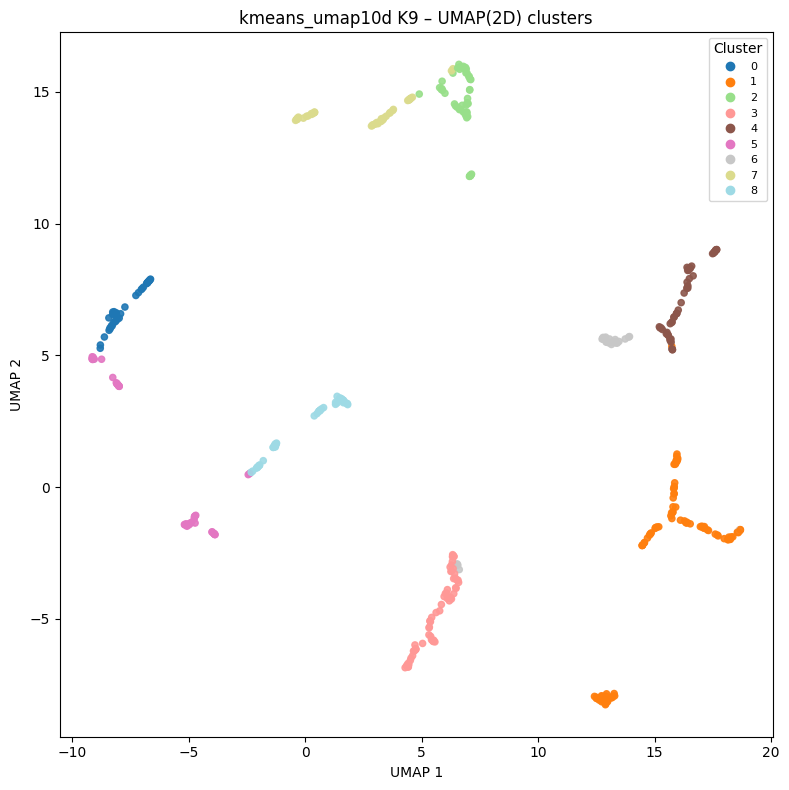

[kmeans_umap10d K9] Saved 2D UMAP clusters to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K9_umap2d_clusters.png


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[kmeans_umap10d K9] UMAP 3D embedding shape: (475, 3)


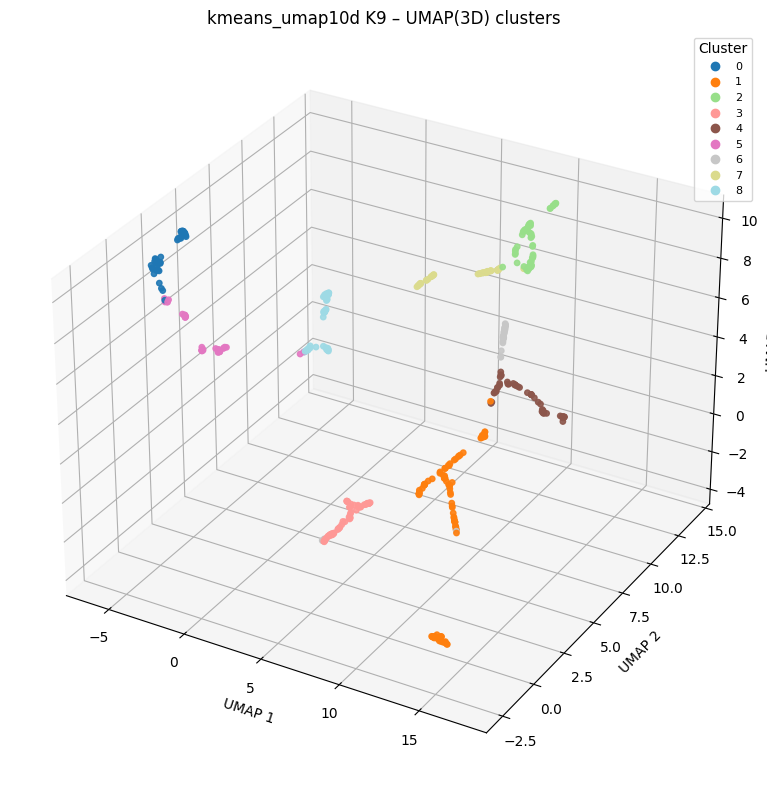

[kmeans_umap10d K9] Saved 3D UMAP clusters to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K9_umap3d_clusters.png


In [44]:
# Visual UMAP cluster plots (2D + 3D) for best KMeans on UMAP10D
save_umap_cluster_scatter_2d_3d(
    X_for_umap=X_for_clustering,          # here: X_umap_hd (10D)
    df_meta=df_meta,
    labels=best_kmeans_labels,
    base_dir=BEST_KMEANS_DIR,
    algo_tag="kmeans_umap10d",
    param_tag=f"K{best_K_kmeans}",
    n_neighbors=10,
    min_dist=0.09,
    random_state=RANDOM_STATE,
)


###  NEw version:

In [55]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

def save_umap_cluster_scatter_2d_3d(
    X_for_umap,
    df_meta,
    labels,
    base_dir: Path,
    algo_tag: str,
    param_tag: str,
    n_neighbors: int = 30,
    min_dist: float = 0.05,
    random_state: int = 42,
):
    """
    1) Compute UMAP(2D) + draw:
         - points colored by patient (patient_codes),
         - edges colored by condition (edgecolors),
         - per-cluster ellipses ('clouds') with IDs.
    2) Compute UMAP(3D) + draw:
         - points colored by patient_codes,
         - edges by condition,
         - cluster centroids with text labels,
         - save several viewing angles to show depth better.
    """

    X_for_umap = np.asarray(X_for_umap)
    labels = np.asarray(labels)

    if X_for_umap.shape[0] != len(labels):
        raise ValueError(f"X_for_umap rows ({X_for_umap.shape[0]}) != labels ({len(labels)})")
    if len(df_meta) != len(labels):
        raise ValueError(f"df_meta ({len(df_meta)}) != labels ({len(labels)})")

    base_dir.mkdir(parents=True, exist_ok=True)

    # ------------------------ UMAP 2D ------------------------
    reducer_2d = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric="euclidean",
        random_state=random_state,
    )
    emb2 = reducer_2d.fit_transform(X_for_umap)
    print(f"[{algo_tag} {param_tag}] UMAP 2D embedding shape:", emb2.shape)

    fig2d, ax2d = plt.subplots(figsize=(8, 8))

    # Points: patient colors, condition edges
    sc = ax2d.scatter(
        emb2[:, 0],
        emb2[:, 1],
        c=patient_codes,       # global: patient-coded colors
        cmap="tab20",
        s=25,
        alpha=0.9,
        edgecolors=edgecolors, # global: condition edgecolors
        linewidths=0.6,
    )

    ax2d.set_title(f"{algo_tag} {param_tag} – UMAP(2D) clusters", fontsize=12)
    ax2d.set_xlabel("UMAP 1", fontsize=10)
    ax2d.set_ylabel("UMAP 2", fontsize=10)

    # Patient legend (color)
    cmap_obj = sc.cmap
    norm = plt.Normalize(vmin=patient_codes.min(), vmax=patient_codes.max())
    patient_handles, patient_labels_list = [], []
    for code, pid in enumerate(patient_uniques):
        patient_handles.append(
            plt.Line2D(
                [], [], marker="o", linestyle="",
                markersize=6,
                markerfacecolor=cmap_obj(norm(code)),
                markeredgecolor="black", linewidth=0,
            )
        )
        patient_labels_list.append(pid)
    leg_pat = ax2d.legend(
        patient_handles,
        patient_labels_list,
        title="patient_id",
        fontsize=7,
        loc="best",
    )
    ax2d.add_artist(leg_pat)

    # Condition legend (edge color)
    cond_handles, cond_labels_list = [], []
    for cond_name in cond_uniques:
        cond_handles.append(
            plt.Line2D(
                [], [], marker="o", linestyle="",
                markersize=6,
                markerfacecolor="lightgray",
                markeredgecolor=cond_edge_map.get(cond_name, "black"),
                linewidth=1.0,
            )
        )
        cond_labels_list.append(cond_name)
    ax2d.legend(
        cond_handles,
        cond_labels_list,
        title="condition (edge color)",
        fontsize=7,
        loc="upper left",
    )

    # --- Cluster "clouds" as ellipses around points ---
    unique_clusters = np.unique(labels)
    for cl in unique_clusters:
        mask = labels == cl
        pts = emb2[mask]
        if pts.shape[0] < 2:
            # too few points for covariance; skip
            continue

        # mean + covariance of cluster in 2D
        mean = pts.mean(axis=0)
        cov = np.cov(pts, rowvar=False)

        # eigen-decomposition
        vals, vecs = np.linalg.eigh(cov)
        order = np.argsort(vals)[::-1]
        vals = vals[order]
        vecs = vecs[:, order]

        # ellipse angle
        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

        # width/height = scaling factor * sqrt(eigenvalues)
        # scale controls how "big" the cloud is
        scale = 2.5
        major_var = max(vals[0], 1e-9)
        minor_var = max(vals[1], 1e-9)
        width = 2 * scale * np.sqrt(major_var)
        height = 2 * scale * np.sqrt(minor_var)

        # color for hull only: use tab20 by cluster index
        hull_color = plt.cm.tab20((int(cl) % 20) / 20.0)

        ell = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            facecolor=hull_color,
            edgecolor=hull_color,
            alpha=0.15,
            linewidth=1.5,
        )
        ax2d.add_patch(ell)

        # ---- cluster label OUTSIDE the cloud, along major axis ----
        # major axis direction (unit vector)
        major_vec = vecs[:, 0]
        # semi-major axis length
        a = scale * np.sqrt(major_var)
        # put text a bit beyond the ellipse boundary
        label_offset = 1.2 * a
        label_pos = mean + major_vec * label_offset

        ax2d.text(
            label_pos[0], label_pos[1],
            str(cl),
            fontsize=8,
            weight="bold",
            ha="center",
            va="center",
            color=hull_color,   # same color as cloud
        )


    plt.tight_layout()
    out_2d = base_dir / f"{algo_tag}_{param_tag}_umap2d_clustersv2_patientcolors_hulls.png"
    plt.show()
    fig2d.savefig(out_2d, dpi=150)
    plt.close(fig2d)
    print(f"[{algo_tag} {param_tag}] Saved 2D UMAP (patient-colored + cluster hulls) to: {out_2d}")

    # ------------------------ UMAP 3D ------------------------
    reducer_3d = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=3,
        metric="euclidean",
        random_state=random_state,
    )
    emb3 = reducer_3d.fit_transform(X_for_umap)
    print(f"[{algo_tag} {param_tag}] UMAP 3D embedding shape:", emb3.shape)

    # We’ll make ONE 3D scatter and save multiple viewing angles.
    fig3d = plt.figure(figsize=(8, 8))
    ax3d = fig3d.add_subplot(111, projection="3d")

    p3d = ax3d.scatter(
        emb3[:, 0],
        emb3[:, 1],
        emb3[:, 2],
        c=patient_codes,       # still patient colors
        cmap="tab20",
        s=15,
        alpha=0.9,
        edgecolors=edgecolors, # condition edges
        linewidths=0.4,
        depthshade=True,
    )

    ax3d.set_title(f"{algo_tag} {param_tag} – UMAP(3D) (patient colors)", fontsize=11)
    ax3d.set_xlabel("UMAP 1", fontsize=9)
    ax3d.set_ylabel("UMAP 2", fontsize=9)
    ax3d.set_zlabel("UMAP 3", fontsize=9)

    # Mark cluster centroids with text to help orientation
    for cl in unique_clusters:
        mask = labels == cl
        pts3 = emb3[mask]
        if pts3.shape[0] == 0:
            continue
        center3 = pts3.mean(axis=0)
        ax3d.scatter(
            center3[0], center3[1], center3[2],
            s=50,
            c="k",
            marker="x",
            linewidths=1.5,
        )
        ax3d.text(
            center3[0], center3[1], center3[2],
            str(cl),
            fontsize=8,
            ha="center",
            va="center",
            color="k",
        )

    # Several angles to make depth more obvious
    angles = [
        (20, 30),
        (20, 120),
        (20, 210),
        (70, 45),
    ]
    for i, (elev, azim) in enumerate(angles, start=1):
        ax3d.view_init(elev=elev, azim=azim)
        plt.tight_layout()
        plt.show()
        out_3d = base_dir / f"{algo_tag}_{param_tag}_umap3d_clustersv2_view{i}.png"
        fig3d.savefig(out_3d, dpi=150)
        print(f"[{algo_tag} {param_tag}] Saved 3D UMAP view {i} to: {out_3d}")

    plt.close(fig3d)


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[kmeans_umap10d K9] UMAP 2D embedding shape: (475, 2)


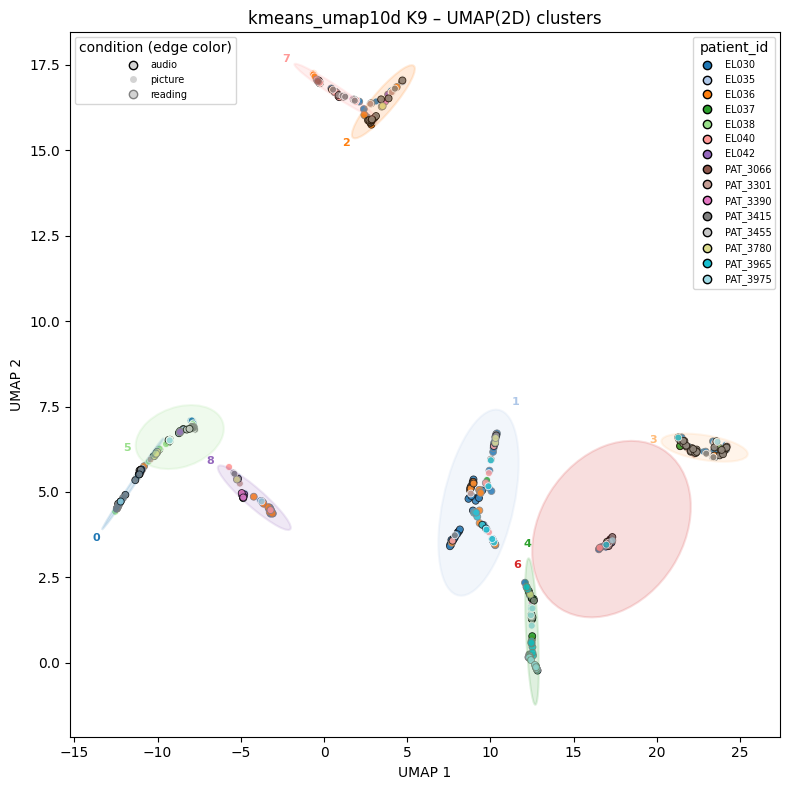

[kmeans_umap10d K9] Saved 2D UMAP (patient-colored + cluster hulls) to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K9_umap2d_clustersv2_patientcolors_hulls.png


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[kmeans_umap10d K9] UMAP 3D embedding shape: (475, 3)


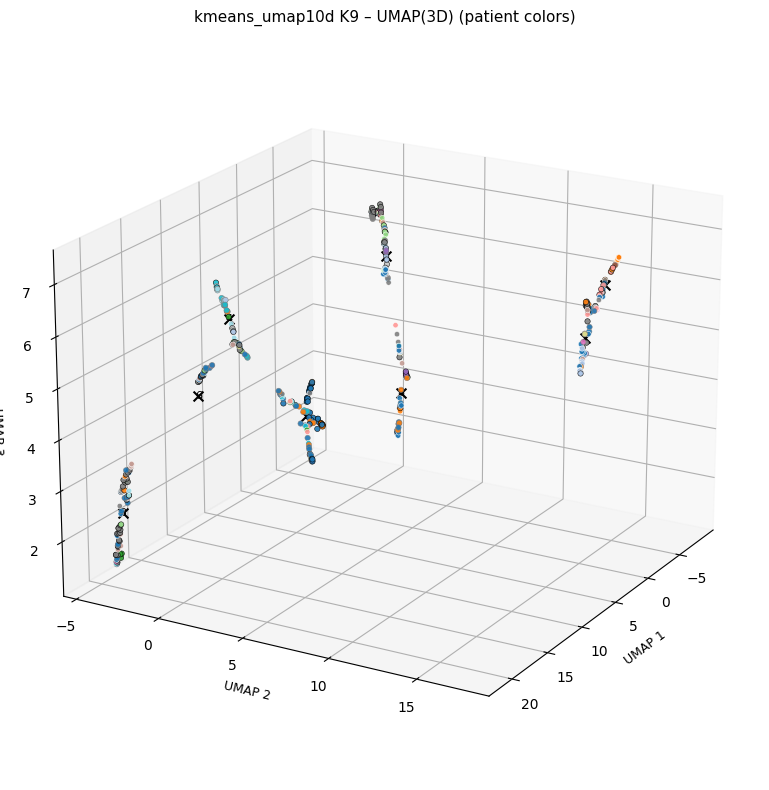

[kmeans_umap10d K9] Saved 3D UMAP view 1 to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K9_umap3d_clustersv2_view1.png


<Figure size 640x480 with 0 Axes>

[kmeans_umap10d K9] Saved 3D UMAP view 2 to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K9_umap3d_clustersv2_view2.png


<Figure size 640x480 with 0 Axes>

[kmeans_umap10d K9] Saved 3D UMAP view 3 to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K9_umap3d_clustersv2_view3.png


<Figure size 640x480 with 0 Axes>

[kmeans_umap10d K9] Saved 3D UMAP view 4 to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K9_umap3d_clustersv2_view4.png


In [56]:
save_umap_cluster_scatter_2d_3d(
    X_for_umap=X_for_clustering,    # 10D UMAP space
    df_meta=df_meta,
    labels=best_kmeans_labels,
    base_dir=BEST_KMEANS_DIR,
    algo_tag="kmeans_umap10d",
    param_tag=f"K{best_K_kmeans}",
    n_neighbors=30,
    min_dist=0.05,
    random_state=RANDOM_STATE,
)


In [57]:
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)


def save_umap3d_rotating_gifs(
    emb3,
    labels,
    df_meta,
    base_dir,
    algo_tag: str,
    param_tag: str,
    init_elev: float = 20,
    init_azim: float = 30,
):
    """
    Make two GIFs of a 3D embedding with patient colors + condition edges and
    spherical 'cloud balls' around each cluster:

      1) Rotate camera around z-axis (azimuth 0..360, elev fixed).
      2) Rotate camera in elevation (0..360, azimuth fixed).

    Parameters
    ----------
    emb3 : array, shape (n_samples, 3)
        3D embedding (e.g. UMAP 3D).
    labels : array, shape (n_samples,)
        Cluster labels (e.g. best-K KMeans).
    df_meta : DataFrame
        Only used to check alignment.
    base_dir : Path
        Where to save GIFs.
    algo_tag : str
        E.g. 'kmeans_umap10d'.
    param_tag : str
        E.g. 'K13'.
    init_elev, init_azim : float
        Initial viewing angles for the camera.
    """

    emb3 = np.asarray(emb3)
    labels = np.asarray(labels)

    if emb3.shape[0] != len(labels):
        raise ValueError(f"emb3 rows ({emb3.shape[0]}) != labels ({len(labels)})")
    if len(df_meta) != len(labels):
        raise ValueError(f"df_meta ({len(df_meta)}) != labels ({len(labels)})")

    base_dir.mkdir(parents=True, exist_ok=True)

    unique_clusters = np.unique(labels)

    # ----- Helper: build a single 3D figure with points + cluster balls -----
    def make_base_figure():
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection="3d")

        # Scatter points: patient colors, condition edges
        sc = ax.scatter(
            emb3[:, 0],
            emb3[:, 1],
            emb3[:, 2],
            c=patient_codes,
            cmap="tab20",
            s=15,
            alpha=0.9,
            edgecolors=edgecolors,
            linewidths=0.4,
            depthshade=True,
        )

        ax.set_title(f"{algo_tag} {param_tag} – UMAP(3D)", fontsize=11)
        ax.set_xlabel("UMAP 1", fontsize=9)
        ax.set_ylabel("UMAP 2", fontsize=9)
        ax.set_zlabel("UMAP 3", fontsize=9)

        # Patient legend
        cmap_obj = sc.cmap
        norm = plt.Normalize(vmin=patient_codes.min(), vmax=patient_codes.max())
        patient_handles, patient_labels_list = [], []
        for code, pid in enumerate(patient_uniques):
            patient_handles.append(
                plt.Line2D(
                    [], [], marker="o", linestyle="",
                    markersize=6,
                    markerfacecolor=cmap_obj(norm(code)),
                    markeredgecolor="black",
                    linewidth=0,
                )
            )
            patient_labels_list.append(pid)
        leg_pat = ax.legend(
            patient_handles,
            patient_labels_list,
            title="patient_id",
            fontsize=7,
            loc="best",
        )
        ax.add_artist(leg_pat)

        # Condition legend (edge color)
        cond_handles, cond_labels_list = [], []
        for cond_name in cond_uniques:
            cond_handles.append(
                plt.Line2D(
                    [], [], marker="o", linestyle="",
                    markersize=6,
                    markerfacecolor="lightgray",
                    markeredgecolor=cond_edge_map.get(cond_name, "black"),
                    linewidth=1.0,
                )
            )
            cond_labels_list.append(cond_name)
        ax.legend(
            cond_handles,
            cond_labels_list,
            title="condition (edge color)",
            fontsize=7,
            loc="upper right",
        )

        # ---- Cluster 'cloud balls' (spheres) around each cluster ----
        # Sphere parameterization grid (shared)
        u = np.linspace(0, 2 * np.pi, 25)
        v = np.linspace(0, np.pi, 15)

        for cl in unique_clusters:
            mask = labels == cl
            pts = emb3[mask]
            if pts.shape[0] == 0:
                continue

            center = pts.mean(axis=0)
            # radius ~ 1.5 * std distance from center (avoid zero)
            dists = np.linalg.norm(pts - center, axis=1)
            r = max(dists.std(), 1e-3) * 1.5

            color = plt.cm.tab20((int(cl) % 20) / 20.0)

            xs = center[0] + r * np.outer(np.cos(u), np.sin(v))
            ys = center[1] + r * np.outer(np.sin(u), np.sin(v))
            zs = center[2] + r * np.outer(np.ones_like(u), np.cos(v))

            ax.plot_surface(
                xs,
                ys,
                zs,
                rstride=1,
                cstride=1,
                color=color,
                alpha=0.12,
                linewidth=0,
                antialiased=True,
            )

            # Label just outside the sphere in +z direction
            label_pos = center + np.array([0.0, 0.0, r * 1.1])
            ax.text(
                label_pos[0],
                label_pos[1],
                label_pos[2],
                str(cl),
                fontsize=9,
                weight="bold",
                ha="center",
                va="center",
                color=color,
            )

        # Set a nice initial view
        ax.view_init(elev=init_elev, azim=init_azim)
        return fig, ax

    # ------------------------------------------------------------------
    # 1) Rotate around z-axis: vary azimuth, fixed elevation
    # ------------------------------------------------------------------
    fig_z, ax_z = make_base_figure()

    def update_azim(frame):
        az = frame  # degrees
        ax_z.view_init(elev=init_elev, azim=az)
        return ax_z,

    frames_z = np.linspace(0, 360, 120)  # 120 frames full turn

    anim_z = animation.FuncAnimation(
        fig_z,
        update_azim,
        frames=frames_z,
        interval=50,
        blit=False,
    )

    out_z = base_dir / f"{algo_tag}_{param_tag}_umap3d_rotate_z.gif"
    # Requires pillow installed: `pip install pillow`
    anim_z.save(out_z, writer="pillow", fps=20)
    plt.close(fig_z)
    print(f"[{algo_tag} {param_tag}] Saved rotating Z GIF to: {out_z}")

    # ------------------------------------------------------------------
    # 2) Rotate in elevation: vary elev, fixed azimuth
    # ------------------------------------------------------------------
    fig_e, ax_e = make_base_figure()

    def update_elev(frame):
        el = frame
        ax_e.view_init(elev=el, azim=init_azim)
        return ax_e,

    frames_e = np.linspace(0, 360, 120)

    anim_e = animation.FuncAnimation(
        fig_e,
        update_elev,
        frames=frames_e,
        interval=50,
        blit=False,
    )

    out_e = base_dir / f"{algo_tag}_{param_tag}_umap3d_rotate_elev.gif"
    anim_e.save(out_e, writer="pillow", fps=20)
    plt.close(fig_e)
    print(f"[{algo_tag} {param_tag}] Saved rotating elevation GIF to: {out_e}")


In [58]:
# After you have X_for_clustering = X_umap_hd and best_kmeans_labels:

# Compute a single UMAP(3D) for animation purposes
reducer_3d_for_gif = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    n_components=3,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
emb3_for_gif = reducer_3d_for_gif.fit_transform(X_for_clustering)

# Save rotating GIFs with cluster balls
save_umap3d_rotating_gifs(
    emb3=emb3_for_gif,
    labels=best_kmeans_labels,
    df_meta=df_meta,
    base_dir=BEST_KMEANS_DIR,
    algo_tag="kmeans_umap10d",
    param_tag=f"K{best_K_kmeans}",
    init_elev=20,
    init_azim=30,
)


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[kmeans_umap10d K9] Saved rotating Z GIF to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K9_umap3d_rotate_z.gif
[kmeans_umap10d K9] Saved rotating elevation GIF to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\kmeans_umap10d_bestK\kmeans_umap10d_K9_umap3d_rotate_elev.gif


### STATS


=== KMeans statistics on UMAP(10D) ===
     K     inertia  silhouette  n_clusters_found
0    6  446.629700    0.613507                 6
1    7  350.018921    0.545359                 7
2    8  282.269257    0.539917                 8
3    9  220.621033    0.555529                 9
4   10  195.175903    0.523430                10
5   11  170.762115    0.521381                11
6   12  148.000931    0.514709                12
7   13  130.258972    0.513193                13
8   14  118.002899    0.531325                14
9   15  106.735359    0.516598                15
10  16   95.816040    0.525490                16
11  17   85.966957    0.520141                17
12  18   77.245911    0.517672                18
13  19   70.217789    0.521341                19
14  20   66.531769    0.527177                20
15  21   63.110245    0.503150                21
16  22   59.819016    0.517338                22
17  23   56.728027    0.502565                23
18  24   52.965233    0.50545

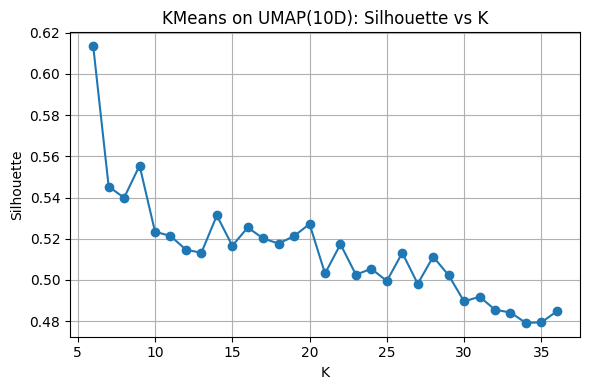

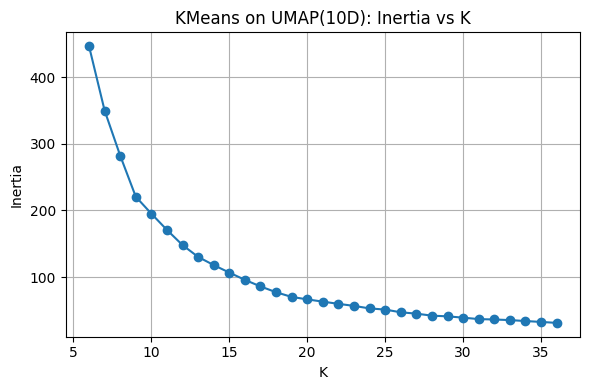

[KMeans UMAP10D] Best K over all: K=6 (sil=0.6135)


In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\n=== KMeans statistics on UMAP(10D) ===")

# 1) Build DataFrame
kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df = kmeans_results_df.sort_values("K")
print(kmeans_results_df[["K", "inertia", "silhouette", "n_clusters_found"]])

# 2) Silhouette vs K
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    kmeans_results_df["K"],
    kmeans_results_df["silhouette"],
    marker="o",
)
ax.set_xlabel("K")
ax.set_ylabel("Silhouette")
ax.set_title("KMeans on UMAP(10D): Silhouette vs K")
ax.grid(True)
plt.tight_layout()
plt.show()

# 3) Inertia vs K (elbow plot)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    kmeans_results_df["K"],
    kmeans_results_df["inertia"],
    marker="o",
)
ax.set_xlabel("K")
ax.set_ylabel("Inertia")
ax.set_title("KMeans on UMAP(10D): Inertia vs K")
ax.grid(True)
plt.tight_layout()
plt.show()

# 4) Quick summary: best K by silhouette (any K)
def safe_argmax_sil(df):
    if df["silhouette"].dropna().empty:
        return None, np.nan
    idx = df["silhouette"].idxmax()
    row = df.loc[idx]
    return int(row["K"]), float(row["silhouette"])

best_K_all, best_sil_all = safe_argmax_sil(kmeans_results_df)
if best_K_all is not None:
    print(f"[KMeans UMAP10D] Best K over all: K={best_K_all} (sil={best_sil_all:.4f})")
else:
    print("[KMeans UMAP10D] No valid silhouettes to choose best K.")


## Interpretability: of the UMAP extracted features


=== KMeans statistics on UMAP(10D) ===
     K     inertia  silhouette  n_clusters_found
0    6  446.629700    0.613507                 6
1    7  350.018921    0.545359                 7
2    8  282.269257    0.539917                 8
3    9  220.621033    0.555529                 9
4   10  195.175903    0.523430                10
5   11  170.762115    0.521381                11
6   12  148.000931    0.514709                12
7   13  130.258972    0.513193                13
8   14  118.002899    0.531325                14
9   15  106.735359    0.516598                15
10  16   95.816040    0.525490                16
11  17   85.966957    0.520141                17
12  18   77.245911    0.517672                18
13  19   70.217789    0.521341                19
14  20   66.531769    0.527177                20
15  21   63.110245    0.503150                21
16  22   59.819016    0.517338                22
17  23   56.728027    0.502565                23
18  24   52.965233    0.50545

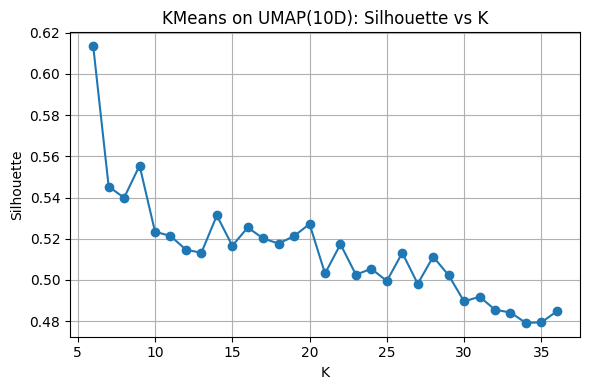

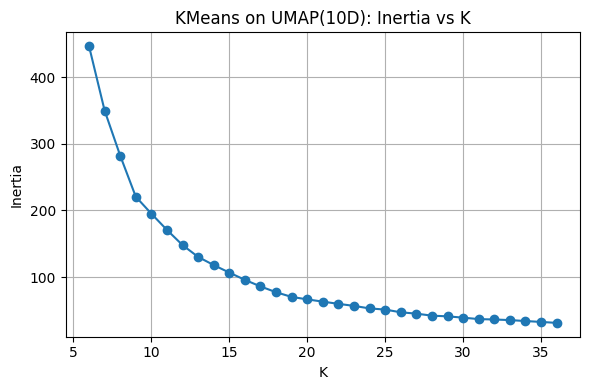

[KMeans UMAP10D] Best K over all (by silhouette): K=6 (sil=0.6135)

=== UMAP(2D) axes meaning: coloring by ERSP features ===


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


emb_axes shape: (475, 2)


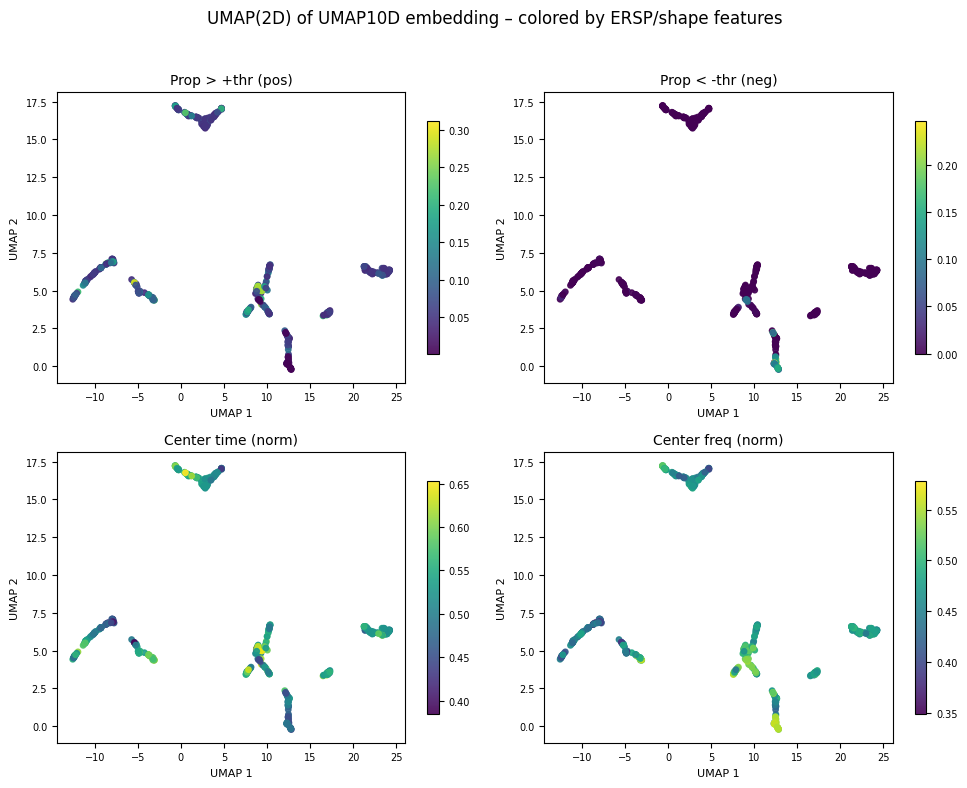

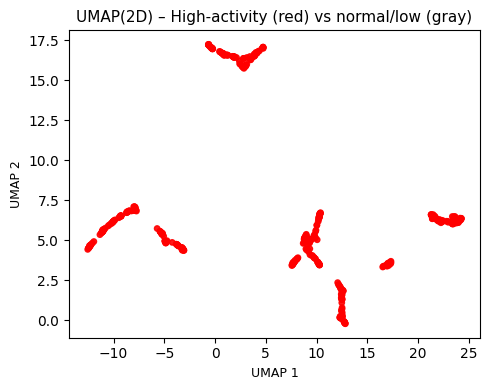


=== Cluster composition sanity checks ===
Using existing best_K_kmeans=9


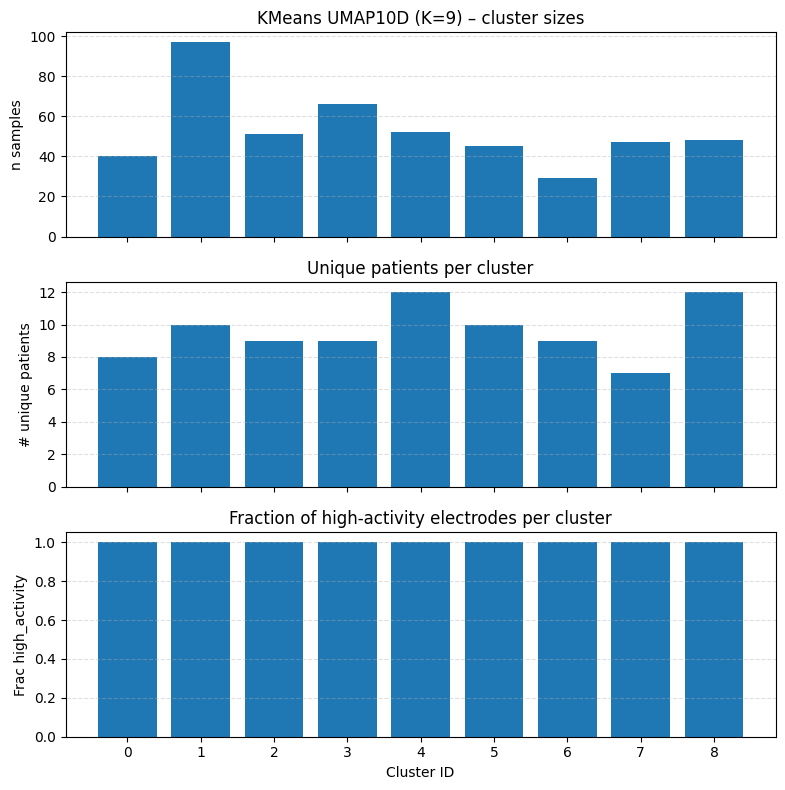

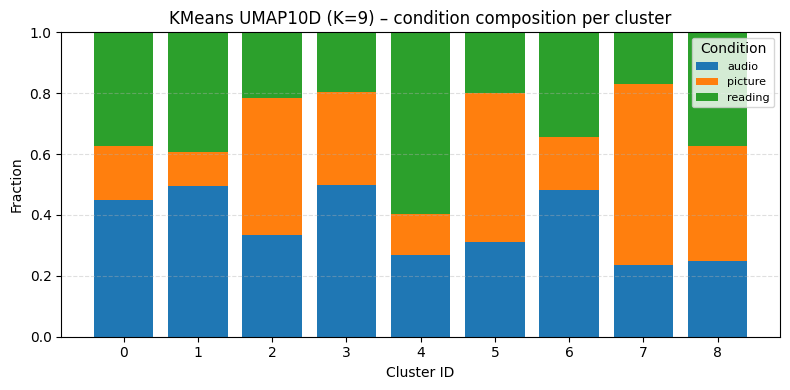


=== KMeans stability check (Adjusted Rand Index) ===
Stability for K=9: Adjusted Rand Index (original vs new KMeans) = 1.0000

=== KMeans stability check (Adjusted Rand Index) V2 ===
Stability for K=9: Adjusted Rand Index (original vs new KMeans) = 1.0000


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# ============================================================
# 1) KMeans statistics on UMAP(10D)
# ============================================================

print("\n=== KMeans statistics on UMAP(10D) ===")

kmeans_results_df = pd.DataFrame(kmeans_results).sort_values("K")
print(kmeans_results_df[["K", "inertia", "silhouette", "n_clusters_found"]])

# --- Silhouette vs K ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    kmeans_results_df["K"],
    kmeans_results_df["silhouette"],
    marker="o",
)
ax.set_xlabel("K")
ax.set_ylabel("Silhouette")
ax.set_title("KMeans on UMAP(10D): Silhouette vs K")
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Inertia vs K (elbow) ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(
    kmeans_results_df["K"],
    kmeans_results_df["inertia"],
    marker="o",
)
ax.set_xlabel("K")
ax.set_ylabel("Inertia")
ax.set_title("KMeans on UMAP(10D): Inertia vs K")
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Best K overall by silhouette ---
def safe_argmax_sil(df):
    if df["silhouette"].dropna().empty:
        return None, np.nan
    idx = df["silhouette"].idxmax()
    row = df.loc[idx]
    return int(row["K"]), float(row["silhouette"])

best_K_all, best_sil_all = safe_argmax_sil(kmeans_results_df)
if best_K_all is not None:
    print(f"[KMeans UMAP10D] Best K over all (by silhouette): K={best_K_all} (sil={best_sil_all:.4f})")
else:
    print("[KMeans UMAP10D] No valid silhouettes to choose best K.")


# ============================================================
# 2) UMAP(2D) axes meaning: color by ERSP/shape features
# ============================================================

print("\n=== UMAP(2D) axes meaning: coloring by ERSP features ===")

# We embed the 10D UMAP space (X_umap_hd) down to 2D for visualization
RANDOM_STATE = 42
X_for_clustering = X_umap_hd  # already defined in your pipeline

umap_axes_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    n_components=2,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
emb_axes = umap_axes_model.fit_transform(X_for_clustering)
print("emb_axes shape:", emb_axes.shape)

# --- Compute center_time_norm and center_freq_norm per electrode ---
center_freq_norm_list = []
center_time_norm_list = []

for arr in ersp_list:
    # arr: (N_FREQ, N_TIME)
    vals = np.abs(arr.astype(np.float64))
    total = vals.sum()
    if total > 0:
        cf = (vals * freq_norm[:, None]).sum() / total
        ct = (vals * time_norm[None, :]).sum() / total
    else:
        cf = np.nan
        ct = np.nan
    center_freq_norm_list.append(cf)
    center_time_norm_list.append(ct)

df_meta["center_freq_norm"] = center_freq_norm_list
df_meta["center_time_norm"] = center_time_norm_list

# --- 4-panel figure: prop_above_pos, prop_below_neg, center_time_norm, center_freq_norm ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

plots_info = [
    ("prop_above_pos", "Prop > +thr (pos)", df_meta["prop_above_pos"]),
    ("prop_below_neg", "Prop < -thr (neg)", df_meta["prop_below_neg"]),
    ("center_time_norm", "Center time (norm)", df_meta["center_time_norm"]),
    ("center_freq_norm", "Center freq (norm)", df_meta["center_freq_norm"]),
]

for ax, (col_name, title, values) in zip(axes, plots_info):
    sc = ax.scatter(
        emb_axes[:, 0],
        emb_axes[:, 1],
        c=values,
        cmap="viridis",
        s=15,
        alpha=0.9,
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("UMAP 1", fontsize=8)
    ax.set_ylabel("UMAP 2", fontsize=8)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.ax.tick_params(labelsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("UMAP(2D) of UMAP10D embedding – colored by ERSP/shape features", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- High-activity flag ---
fig, ax = plt.subplots(figsize=(5, 4))
colors_ha = df_meta["high_activity"].map({True: "red", False: "gray"}).to_numpy()
ax.scatter(
    emb_axes[:, 0],
    emb_axes[:, 1],
    c=colors_ha,
    s=15,
    alpha=0.9,
)
ax.set_title("UMAP(2D) – High-activity (red) vs normal/low (gray)", fontsize=11)
ax.set_xlabel("UMAP 1", fontsize=9)
ax.set_ylabel("UMAP 2", fontsize=9)
plt.tight_layout()
plt.show()


# ============================================================
# 3) Cluster composition sanity checks (for best KMeans on UMAP10D)
# ============================================================

print("\n=== Cluster composition sanity checks ===")

# Try to reuse your best_K_kmeans / best_kmeans_labels (restricted 8<K<20),
# otherwise fall back to best_K_all (global best) from kmeans_results_df.
try:
    best_K = best_K_kmeans
    best_labels = best_kmeans_labels
    print(f"Using existing best_K_kmeans={best_K}")
except NameError:
    if best_K_all is None:
        raise RuntimeError("No best K found and best_K_kmeans not defined.")
    best_K = best_K_all
    best_labels = kmeans_label_dict[best_K]
    print(f"Using best_K_all={best_K} from kmeans_results_df")

df_meta["cluster_kmeans_umap10d_bestK"] = best_labels

cluster_ids = sorted(np.unique(best_labels))

# --- Basic per-cluster stats ---
cluster_sizes = []
uniq_patients_per_cluster = []
frac_high_activity = []

for c in cluster_ids:
    df_c = df_meta[df_meta["cluster_kmeans_umap10d_bestK"] == c]
    cluster_sizes.append(len(df_c))
    uniq_patients_per_cluster.append(df_c["patient_id"].nunique())
    if len(df_c) > 0:
        frac_high_activity.append(df_c["high_activity"].mean())
    else:
        frac_high_activity.append(np.nan)

# A) Bar plots: size, unique patients, fraction high-activity
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

x = np.arange(len(cluster_ids))

axes[0].bar(x, cluster_sizes)
axes[0].set_ylabel("n samples")
axes[0].set_title(f"KMeans UMAP10D (K={best_K}) – cluster sizes")

axes[1].bar(x, uniq_patients_per_cluster)
axes[1].set_ylabel("# unique patients")
axes[1].set_title("Unique patients per cluster")

axes[2].bar(x, frac_high_activity)
axes[2].set_ylabel("Frac high_activity")
axes[2].set_xlabel("Cluster ID")
axes[2].set_title("Fraction of high-activity electrodes per cluster")
axes[2].set_xticks(x)
axes[2].set_xticklabels(cluster_ids)

for ax in axes:
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# B) Condition composition (stacked bar)
conditions = sorted(df_meta["condition"].unique())
condition_colors = {
    cond: color for cond, color in zip(
        conditions,
        ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
    )
}

cond_fracs_per_cluster = {cond: [] for cond in conditions}

for c in cluster_ids:
    df_c = df_meta[df_meta["cluster_kmeans_umap10d_bestK"] == c]
    total_c = len(df_c)
    for cond in conditions:
        if total_c > 0:
            frac = (df_c["condition"] == cond).mean()
        else:
            frac = 0.0
        cond_fracs_per_cluster[cond].append(frac)

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(cluster_ids))

for cond in conditions:
    fracs = np.array(cond_fracs_per_cluster[cond])
    ax.bar(
        x,
        fracs,
        bottom=bottom,
        color=condition_colors.get(cond, "gray"),
        edgecolor="none",
        label=cond,
    )
    bottom += fracs

ax.set_xticks(x)
ax.set_xticklabels(cluster_ids)
ax.set_xlabel("Cluster ID")
ax.set_ylabel("Fraction")
ax.set_title(f"KMeans UMAP10D (K={best_K}) – condition composition per cluster")
ax.legend(title="Condition", fontsize=8)
ax.set_ylim(0, 1.0)
ax.grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# ============================================================
# 4) KMeans stability check (same K, different random_state)
# ============================================================

print("\n=== KMeans stability check (Adjusted Rand Index) ===")

kmeans_stable = KMeans(
    n_clusters=best_K,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE + 123,  # different seed
    verbose=0,
)
kmeans_stable.fit(X_for_clustering)
labels_stable = kmeans_stable.labels_

ari = adjusted_rand_score(best_labels, labels_stable)
print(
    f"Stability for K={best_K}: Adjusted Rand Index (original vs new KMeans) = {ari:.4f}"
)



print("\n=== KMeans stability check (Adjusted Rand Index) V2 ===")

kmeans_stable = KMeans(
    n_clusters=best_K,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE + 300,  # different seed
    verbose=0,
)
kmeans_stable.fit(X_for_clustering)
labels_stable = kmeans_stable.labels_

ari = adjusted_rand_score(best_labels, labels_stable)
print(
    f"Stability for K={best_K}: Adjusted Rand Index (original vs new KMeans) = {ari:.4f}"
)


# GMM


=== GMM sweep on UMAP(10D) features ===

--- GMM on UMAP10D with K=6 ---
Cluster counts      : {0: 52, 1: 133, 2: 79, 3: 96, 4: 69, 5: 46}
Silhouette          : 0.6376090049743652
BIC                 : 1925.1118283218657
AIC                 : 1404.6974778175354
Neg avg log-likely  : 1.2158815
[gmm_umap10d K6] Saved cluster cards to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\gmm_umap10d_cluster_cards\gmm_umap10d_K6_cluster_cards.png

--- GMM on UMAP10D with K=7 ---
Cluster counts      : {0: 59, 1: 96, 2: 46, 3: 69, 4: 79, 5: 74, 6: 52}
Silhouette          : 0.5258999466896057
BIC                 : 1020.2465165567327
AIC                 : 412.402555167675
Neg avg log-likely  : 0.12777297
[gmm_umap10d K7] Saved cluster cards to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\figures\gmm_umap10d_cluster_cards\gmm_umap10d_K7_cluster_cards.png

--- GMM on UMAP10D with K=8 ---
Cluster counts   

C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[gmm_umap10d K9] UMAP 2D embedding shape: (475, 2)


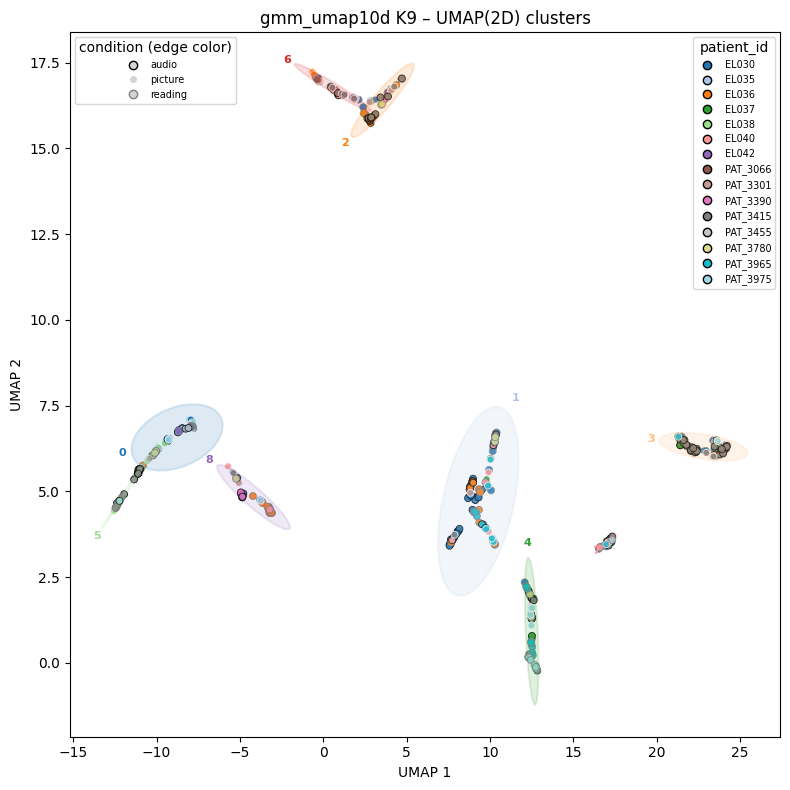

[gmm_umap10d K9] Saved 2D UMAP (patient-colored + cluster hulls) to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\gmm_umap10d_bestK\gmm_umap10d_K9_umap2d_clustersv2_patientcolors_hulls.png


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[gmm_umap10d K9] UMAP 3D embedding shape: (475, 3)


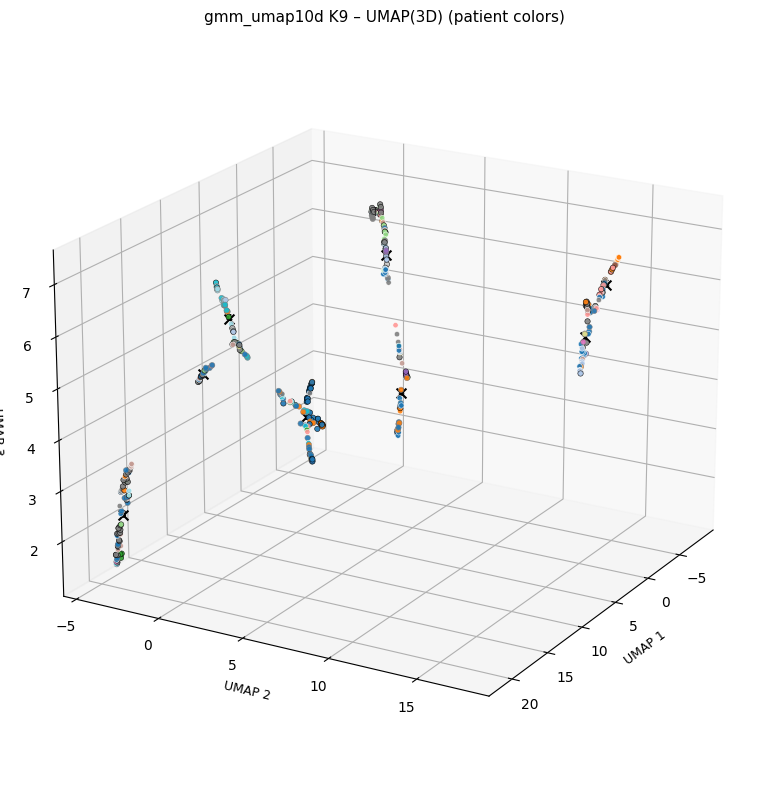

[gmm_umap10d K9] Saved 3D UMAP view 1 to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\gmm_umap10d_bestK\gmm_umap10d_K9_umap3d_clustersv2_view1.png


<Figure size 640x480 with 0 Axes>

[gmm_umap10d K9] Saved 3D UMAP view 2 to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\gmm_umap10d_bestK\gmm_umap10d_K9_umap3d_clustersv2_view2.png


<Figure size 640x480 with 0 Axes>

[gmm_umap10d K9] Saved 3D UMAP view 3 to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\gmm_umap10d_bestK\gmm_umap10d_K9_umap3d_clustersv2_view3.png


<Figure size 640x480 with 0 Axes>

[gmm_umap10d K9] Saved 3D UMAP view 4 to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\gmm_umap10d_bestK\gmm_umap10d_K9_umap3d_clustersv2_view4.png


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[gmm_umap10d K9] Saved rotating Z GIF to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\gmm_umap10d_bestK\gmm_umap10d_K9_umap3d_rotate_z.gif
[gmm_umap10d K9] Saved rotating elevation GIF to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\gmm_umap10d_bestK\gmm_umap10d_K9_umap3d_rotate_elev.gif

=== GMM stability check (Adjusted Rand Index) ===
GMM stability for K=9: Adjusted Rand Index (original vs new GMM) = 0.8864

Saved df_meta with GMM-UMAP10D best-K cluster column to: \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_Lora\02_FBM_Clustering\outputs\clustering\df_meta_with_gmm_umap10d_bestK.tsv


In [64]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import umap

# ============================================================
# 1) Paths for GMM-on-UMAP10D outputs
# ============================================================

FIGURES_GMM_UMAP10D_CLUSTER_CARDS_DIR = (
    ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/figures/gmm_umap10d_cluster_cards"
)
FIGURES_GMM_UMAP10D_CLUSTER_CARDS_DIR.mkdir(parents=True, exist_ok=True)

BEST_GMM_UMAP10D_DIR = (
    ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/gmm_umap10d_bestK"
)
BEST_GMM_UMAP10D_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2) GMM sweep on UMAP(10D) features
# ============================================================

print("\n=== GMM sweep on UMAP(10D) features ===")

# 10D space we cluster on (same as KMeans)
X_for_clustering = X_umap_hd

GMM_K_RANGE = [6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,
               21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36]

gmm_results = []
gmm_label_dict = {}

PLOT_GMM_CLUSTER_CARDS = True  # set False if you want to skip PNGs

for K in GMM_K_RANGE:
    print(f"\n--- GMM on UMAP10D with K={K} ---")
    gmm = GaussianMixture(
        n_components=K,
        covariance_type="diag",   # change to 'full' if you prefer
        random_state=RANDOM_STATE,
        n_init=5,
        max_iter=300,
    )

    gmm.fit(X_for_clustering)
    labels = gmm.predict(X_for_clustering)

    # Silhouette
    unique_labels, counts = np.unique(labels, return_counts=True)
    if len(unique_labels) > 1:
        sil = silhouette_score(X_for_clustering, labels)
    else:
        sil = np.nan

    # BIC/AIC + a simple "inertia-like" score (negative avg log-likelihood)
    bic = gmm.bic(X_for_clustering)
    aic = gmm.aic(X_for_clustering)
    neg_log_like = -gmm.lower_bound_   # avg negative log-likelihood per sample

    print("Cluster counts      :", dict(zip(unique_labels, counts)))
    print("Silhouette          :", sil)
    print("BIC                 :", bic)
    print("AIC                 :", aic)
    print("Neg avg log-likely  :", neg_log_like)

    gmm_results.append({
        "algo": "gmm_umap10d",
        "K": K,
        "silhouette": sil,
        "bic": bic,
        "aic": aic,
        "neg_log_like": neg_log_like,
        "n_clusters_found": len(unique_labels),
    })
    gmm_label_dict[K] = labels.copy()

    # Cluster cards (condition stripe + mean ERSP)
    if PLOT_GMM_CLUSTER_CARDS:
        try:
            save_cluster_cards_generic(
                df_meta=df_meta,
                labels=labels,
                ersp_list=ersp_list,
                algo_tag="gmm_umap10d",
                param_tag=f"K{K}",
                out_dir=FIGURES_GMM_UMAP10D_CLUSTER_CARDS_DIR,
                n_freq=N_FREQ,
                n_time=N_TIME,
            )
        except NameError:
            print("save_cluster_cards_generic is not defined; skipping cluster cards.")

print("\nGMM sweep on UMAP10D finished.")

# ============================================================
# 3) Select best K by silhouette in (8, 20)
# ============================================================

def select_best_k_by_silhouette(results_list, k_key="K", sil_key="silhouette"):
    """
    results_list: list of dicts with keys [k_key, sil_key].
    Returns (best_K, best_sil) or (None, None) if no valid entries
    with 8 < K < 20.
    """
    candidates = [
        (r[k_key], r.get(sil_key, np.nan))
        for r in results_list
        if (r[k_key] > 8 and r[k_key] < 20 and not np.isnan(r.get(sil_key, np.nan)))
    ]
    if not candidates:
        return None, None
    best_K, best_sil = max(candidates, key=lambda t: t[1])
    return best_K, best_sil

print("\n=== Selecting best K by silhouette for GMM on UMAP10D (8 < K < 20) ===")

gmm_results_df = pd.DataFrame(gmm_results).sort_values("K")
best_K_gmm, best_sil_gmm = select_best_k_by_silhouette(
    gmm_results,
    k_key="K",
    sil_key="silhouette",
)

if best_K_gmm is not None:
    print(f"[GMM UMAP10D] Best K in (8,20): K={best_K_gmm} (sil={best_sil_gmm:.4f})")
    best_gmm_labels = gmm_label_dict[best_K_gmm]

    # Attach labels to df_meta
    df_meta["cluster_gmm_umap10d_bestK"] = best_gmm_labels

    # Save labels to disk
    np.save(
        BEST_GMM_UMAP10D_DIR / f"gmm_umap10d_bestK_labels_K{best_K_gmm}.npy",
        best_gmm_labels,
    )
    print(
        "[GMM UMAP10D] Saved best-K labels to:",
        BEST_GMM_UMAP10D_DIR / f"gmm_umap10d_bestK_labels_K{best_K_gmm}.npy",
    )

    # Export per-cluster images + centroids, if helper exists
    try:
        export_best_cluster_images(
            df_meta=df_meta,
            labels=best_gmm_labels,
            ersp_list=ersp_list,
            algo_name="gmm_umap10d",
            param_tag=f"K{best_K_gmm}",
            base_dir=BEST_GMM_UMAP10D_DIR,
            image_suffix=".png",
            save_centroid_npy=True,
        )
    except NameError:
        print("export_best_cluster_images not defined; skipping image export.")

    # ========================================================
    # 4) UMAP(2D/3D) cluster visualizations for best GMM
    # ========================================================

    # 2D hulls + 3D multi-view PNGs
    try:
        save_umap_cluster_scatter_2d_3d(
            X_for_umap=X_for_clustering,
            df_meta=df_meta,
            labels=best_gmm_labels,
            base_dir=BEST_GMM_UMAP10D_DIR,
            algo_tag="gmm_umap10d",
            param_tag=f"K{best_K_gmm}",
            n_neighbors=30,
            min_dist=0.05,
            random_state=RANDOM_STATE,
        )
    except NameError:
        print("save_umap_cluster_scatter_2d_3d not defined; skipping 2D/3D PNGs.")

    # 3D rotating GIFs (cluster balls)
    try:
        # Compute a single 3D UMAP just for GIFs
        reducer_3d_for_gif = umap.UMAP(
            n_neighbors=30,
            min_dist=0.05,
            n_components=3,
            metric="euclidean",
            random_state=RANDOM_STATE,
        )
        emb3_for_gif = reducer_3d_for_gif.fit_transform(X_for_clustering)

        save_umap3d_rotating_gifs(
            emb3=emb3_for_gif,
            labels=best_gmm_labels,
            df_meta=df_meta,
            base_dir=BEST_GMM_UMAP10D_DIR,
            algo_tag="gmm_umap10d",
            param_tag=f"K{best_K_gmm}",
            init_elev=20,
            init_azim=30,
        )
    except NameError:
        print("save_umap3d_rotating_gifs not defined; skipping 3D GIFs.")
else:
    print("[GMM UMAP10D] No valid K in (8,20) with non-NaN silhouette.")


# ============================================================
# 5) GMM stability check (Adjusted Rand Index) for best_K_gmm
# ============================================================

if best_K_gmm is not None:
    print("\n=== GMM stability check (Adjusted Rand Index) ===")

    labels_original = best_gmm_labels

    gmm_stable = GaussianMixture(
        n_components=best_K_gmm,
        covariance_type="diag",  # keep in sync with above
        random_state=RANDOM_STATE + 123,
        n_init=5,
        max_iter=300,
    )
    gmm_stable.fit(X_for_clustering)
    labels_stable = gmm_stable.predict(X_for_clustering)

    ari_gmm = adjusted_rand_score(labels_original, labels_stable)
    print(
        f"GMM stability for K={best_K_gmm}: "
        f"Adjusted Rand Index (original vs new GMM) = {ari_gmm:.4f}"
    )


# ============================================================
# 6) Save df_meta with GMM best-K column
# ============================================================

out_tsv_gmm = ANALYSIS_ROOT / r"02_FBM_Clustering/outputs/clustering/df_meta_with_gmm_umap10d_bestK.tsv"
df_meta.to_csv(out_tsv_gmm, sep="\t", index=False)
print("\nSaved df_meta with GMM-UMAP10D best-K cluster column to:", out_tsv_gmm)



=== GMM statistics on UMAP(10D) ===
Columns in gmm_results_df: ['algo', 'K', 'silhouette', 'bic', 'aic', 'neg_log_like', 'n_clusters_found']
     K  silhouette          bic          aic  n_clusters_found
0    6    0.637609  1925.111828  1404.697478                 6
1    7    0.525900  1020.246517   412.402555                 7
2    8    0.512461   231.171107  -464.102465                 8
3    9    0.548314  -437.566639 -1220.269822                 9
4   10    0.536463  -724.238353 -1594.371147                10
5   11    0.483324 -1137.136754 -2094.699159                11
6   12    0.532861 -1659.594333 -2704.586349                12
7   13    0.508405 -2034.912924 -3167.334550                13
8   14    0.525763 -2236.713703 -3456.564940                14
9   15    0.516601 -2484.100985 -3791.381833                15
10  16    0.492592 -2979.306140 -4374.016600                16
11  17    0.490942 -3232.812936 -4714.953006                17
12  18    0.519592 -3531.680415 -5101.2

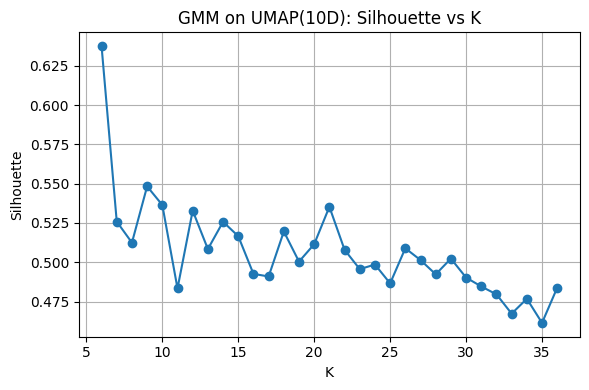

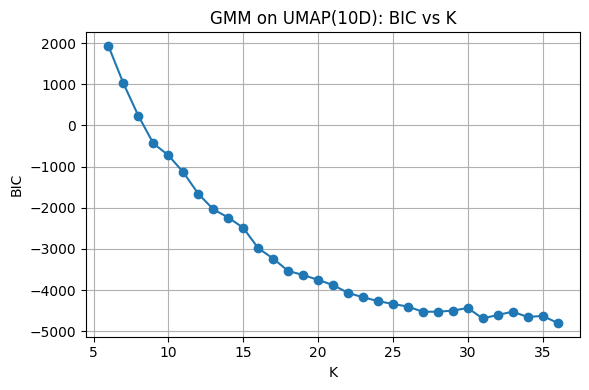

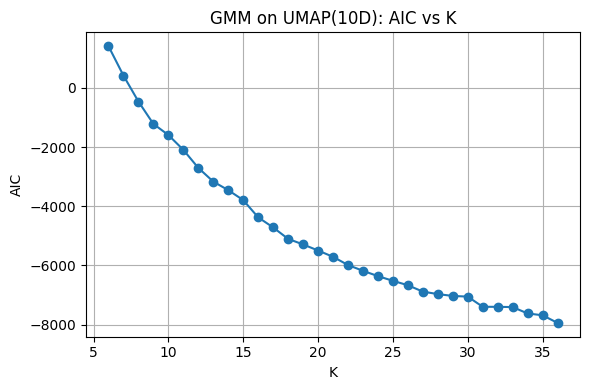

[GMM UMAP10D] Best K over all (by silhouette): K=6 (sil=0.6376)
Using existing best_K_gmm=9

=== GMM stability check (Adjusted Rand Index) ===
GMM stability for K=9: Adjusted Rand Index (original vs new GMM) = 0.8864


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

# ============================================================
# GMM statistics on UMAP(10D)
# ============================================================

print("\n=== GMM statistics on UMAP(10D) ===")

gmm_results_df = pd.DataFrame(gmm_results).sort_values("K")
print("Columns in gmm_results_df:", gmm_results_df.columns.tolist())

# Print a compact table of the most relevant columns if they exist
cols_to_show = ["K", "silhouette", "bic", "aic", "n_clusters_found"]
cols_to_show = [c for c in cols_to_show if c in gmm_results_df.columns]
print(gmm_results_df[cols_to_show])

# 1) Silhouette vs K
if "silhouette" in gmm_results_df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(
        gmm_results_df["K"],
        gmm_results_df["silhouette"],
        marker="o",
    )
    ax.set_xlabel("K")
    ax.set_ylabel("Silhouette")
    ax.set_title("GMM on UMAP(10D): Silhouette vs K")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No 'silhouette' column in gmm_results_df – skipping Silhouette vs K plot.")

# 2) BIC vs K (if available)
if "bic" in gmm_results_df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(
        gmm_results_df["K"],
        gmm_results_df["bic"],
        marker="o",
    )
    ax.set_xlabel("K")
    ax.set_ylabel("BIC")
    ax.set_title("GMM on UMAP(10D): BIC vs K")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No 'bic' column in gmm_results_df – skipping BIC vs K plot.")

# 3) AIC vs K (if available)
if "aic" in gmm_results_df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(
        gmm_results_df["K"],
        gmm_results_df["aic"],
        marker="o",
    )
    ax.set_xlabel("K")
    ax.set_ylabel("AIC")
    ax.set_title("GMM on UMAP(10D): AIC vs K")
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("No 'aic' column in gmm_results_df – skipping AIC vs K plot.")

# 4) Best K overall by silhouette
def safe_argmax_sil(df):
    if "silhouette" not in df.columns:
        return None, np.nan
    if df["silhouette"].dropna().empty:
        return None, np.nan
    idx = df["silhouette"].idxmax()
    row = df.loc[idx]
    return int(row["K"]), float(row["silhouette"])

best_K_gmm_all, best_sil_gmm_all = safe_argmax_sil(gmm_results_df)
if best_K_gmm_all is not None:
    print(f"[GMM UMAP10D] Best K over all (by silhouette): K={best_K_gmm_all} (sil={best_sil_gmm_all:.4f})")
else:
    print("[GMM UMAP10D] No valid silhouettes to choose best K.")

# If you already had a best_K_gmm from your 8<K<20 selection, reuse it;
# otherwise fall back to best_K_gmm_all
try:
    best_K_gmm = best_K_gmm  # noqa: F821 (if already defined earlier)
    best_gmm_labels = best_gmm_labels
    print(f"Using existing best_K_gmm={best_K_gmm}")
except NameError:
    if best_K_gmm_all is None:
        raise RuntimeError("No best K for GMM found.")
    best_K_gmm = best_K_gmm_all
    best_gmm_labels = gmm_label_dict[best_K_gmm]
    print(f"Using best_K_gmm_all={best_K_gmm} from gmm_results_df")

# Attach labels to df_meta (for later interpretation if you want)
df_meta["cluster_gmm_umap10d_bestK"] = best_gmm_labels

# ============================================================
# GMM stability check (Adjusted Rand Index)
# ============================================================

print("\n=== GMM stability check (Adjusted Rand Index) ===")

X_for_clustering = X_umap_hd  # same as for KMeans

# Original labels come from your previous GMM sweep (gmm_label_dict)
labels_original = best_gmm_labels

# Re-fit a new GMM with same K but different random_state
gmm_stable = GaussianMixture(
    n_components=best_K_gmm,
    covariance_type="diag",  # adjust if you used 'full' or another type
    random_state=RANDOM_STATE + 123,
    n_init=5,
    max_iter=300,
)
gmm_stable.fit(X_for_clustering)
labels_stable = gmm_stable.predict(X_for_clustering)

ari_gmm = adjusted_rand_score(labels_original, labels_stable)
print(
    f"GMM stability for K={best_K_gmm}: "
    f"Adjusted Rand Index (original vs new GMM) = {ari_gmm:.4f}"
)



KMeans results (K, silhouette):
     K  silhouette
0    6    0.613507
1    7    0.545359
2    8    0.539917
3    9    0.555529
4   10    0.523430
5   11    0.521381
6   12    0.514709
7   13    0.513193
8   14    0.531325
9   15    0.516598
10  16    0.525490
11  17    0.520141
12  18    0.517672
13  19    0.521341
14  20    0.527177
15  21    0.503150
16  22    0.517338
17  23    0.502565
18  24    0.505459
19  25    0.499470
20  26    0.513192
21  27    0.498137
22  28    0.511310
23  29    0.502254
24  30    0.489581
25  31    0.491885
26  32    0.485573
27  33    0.484196
28  34    0.479166
29  35    0.479426
30  36    0.484774

GMM results (K, silhouette):
     K  silhouette
0    6    0.637609
1    7    0.525900
2    8    0.512461
3    9    0.548314
4   10    0.536463
5   11    0.483324
6   12    0.532861
7   13    0.508405
8   14    0.525763
9   15    0.516601
10  16    0.492592
11  17    0.490942
12  18    0.519592
13  19    0.500402
14  20    0.511516
15  21    0.535303
16  22

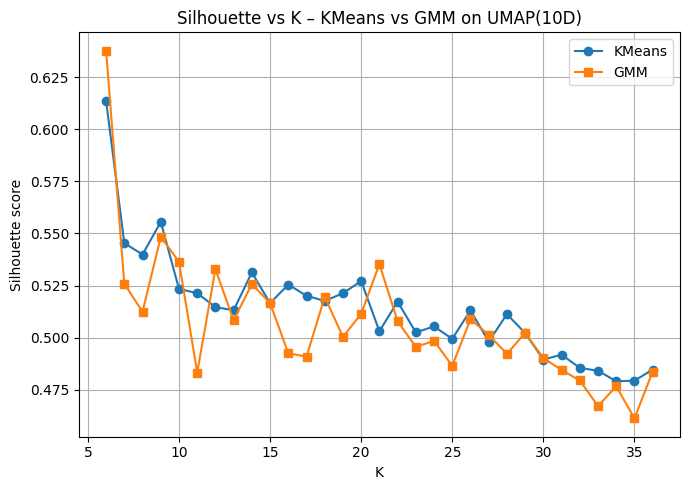

[KMeans] Best K=6, silhouette=0.6135
[GMM] Best K=6, silhouette=0.6376


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming these already exist from your sweeps:
# kmeans_results, gmm_results

# ----------------------------
# Build DataFrames
# ----------------------------
kmeans_results_df = pd.DataFrame(kmeans_results).sort_values("K")
gmm_results_df    = pd.DataFrame(gmm_results).sort_values("K")

print("\nKMeans results (K, silhouette):")
print(kmeans_results_df[["K", "silhouette"]])

print("\nGMM results (K, silhouette):")
print(gmm_results_df[["K", "silhouette"]])

# ----------------------------
# Silhouette vs K (combined)
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

if "silhouette" in kmeans_results_df.columns:
    ax.plot(
        kmeans_results_df["K"],
        kmeans_results_df["silhouette"],
        marker="o",
        label="KMeans",
    )

if "silhouette" in gmm_results_df.columns:
    ax.plot(
        gmm_results_df["K"],
        gmm_results_df["silhouette"],
        marker="s",
        label="GMM",
    )

ax.set_xlabel("K")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette vs K – KMeans vs GMM on UMAP(10D)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Print best K per algorithm
# ----------------------------
def best_K_by_sil(df, name):
    if "silhouette" not in df.columns or df["silhouette"].dropna().empty:
        print(f"[{name}] No valid silhouettes.")
        return
    idx = df["silhouette"].idxmax()
    row = df.loc[idx]
    print(f"[{name}] Best K={int(row['K'])}, silhouette={row['silhouette']:.4f}")

best_K_by_sil(kmeans_results_df, "KMeans")
best_K_by_sil(gmm_results_df, "GMM")


X_for_clustering shape: (475, 10)
[KMeans] Using existing best_K_kmeans=9
[GMM] Using existing best_K_gmm=9

=== OPTION 1: Multi-seed stability (KMeans & GMM) ===

[KMeans] Multi-seed stability at K=9, 10 seeds
KMeans ARI matrix (first 3x3):
[[1.         1.         0.99599187]
 [1.         1.         0.99599187]
 [0.99599187 0.99599187 1.        ]]
KMeans multi-seed ARI mean=0.9992, std=0.0016


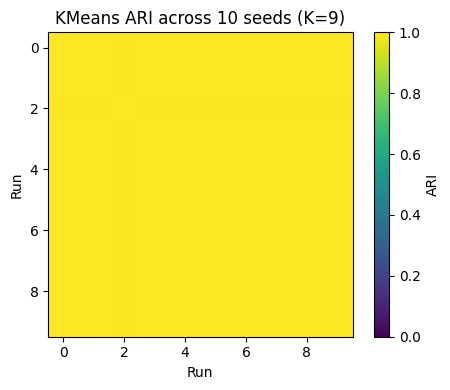

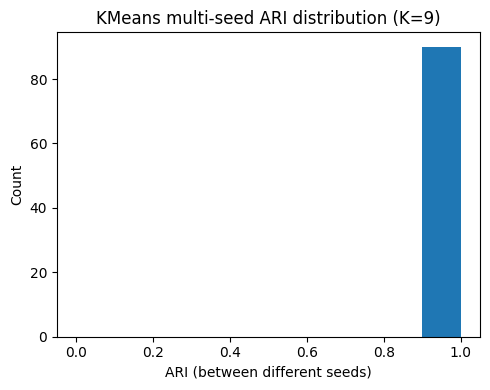


[GMM] Multi-seed stability at K=9, 10 seeds
GMM ARI matrix (first 3x3):
[[1.         0.88640764 0.93362188]
 [0.88640764 1.         0.94991267]
 [0.93362188 0.94991267 1.        ]]
GMM multi-seed ARI mean=0.9167, std=0.0665


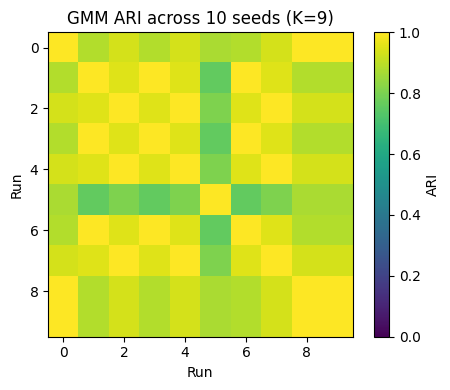

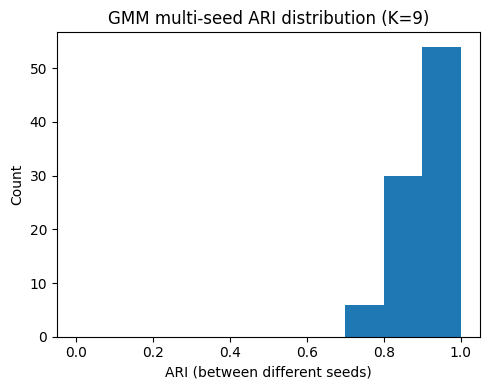


=== OPTION 2: Bootstrap/subsample stability (KMeans & GMM) ===
Using 20 runs, each with 380/475 samples (with replacement).

[KMeans] Bootstrap-like stability at K=9
KMeans bootstrap ARI matrix (first 3x3):
[[1.         0.9352319  0.73040787]
 [0.9352319  1.         0.77473239]
 [0.73040787 0.77473239 1.        ]]
KMeans bootstrap ARI mean=0.9086, std=0.0649


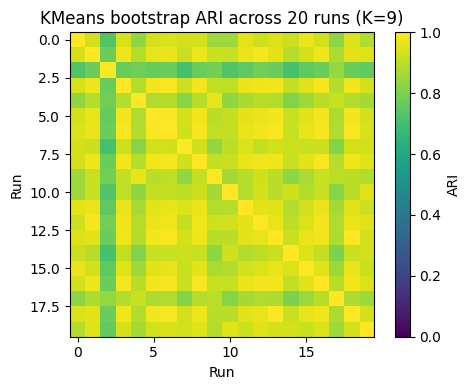

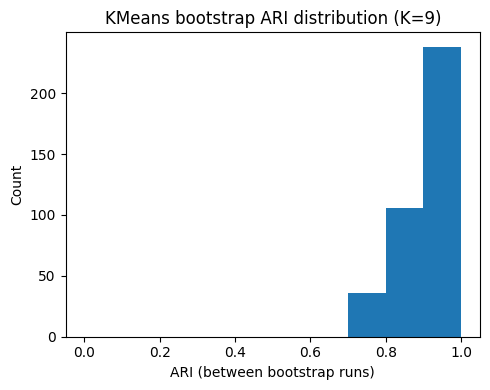


[GMM] Bootstrap-like stability at K=9
GMM bootstrap ARI matrix (first 3x3):
[[1.         0.9442924  0.9127111 ]
 [0.9442924  1.         0.94927331]
 [0.9127111  0.94927331 1.        ]]
GMM bootstrap ARI mean=0.8627, std=0.0740


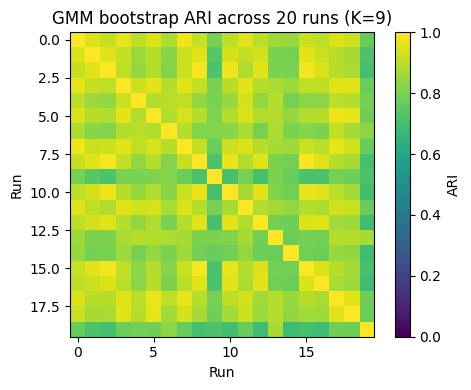

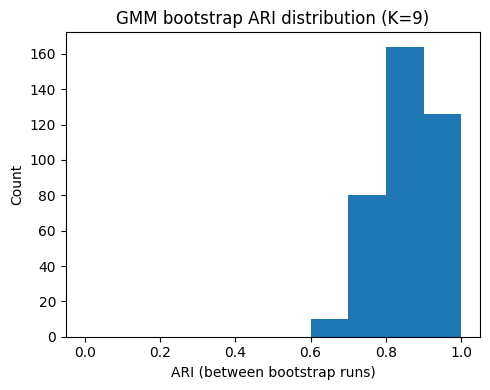

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score

# ============================================================
# CONFIG
# ============================================================

X_for_clustering = X_umap_hd  # UMAP(10D) space
n_samples = X_for_clustering.shape[0]

N_SEEDS = 10         # Option 1: number of random seeds per algo (multi-seed)
N_BOOT = 20          # Option 2: number of bootstrap/subsample runs
BOOT_FRACTION = 0.8  # fraction of samples per bootstrap run

print("X_for_clustering shape:", X_for_clustering.shape)

# ============================================================
# Helper: get best K by silhouette from results list
# ============================================================

def best_K_by_silhouette_from_results(results, k_key="K", sil_key="silhouette"):
    if not results:
        return None, np.nan
    df = pd.DataFrame(results)
    if sil_key not in df.columns:
        return None, np.nan
    if df[sil_key].dropna().empty:
        return None, np.nan
    idx = df[sil_key].idxmax()
    row = df.loc[idx]
    return int(row[k_key]), float(row[sil_key])


# ============================================================
# Determine best K for KMeans and GMM if not already defined
# ============================================================

# ---- KMeans best K ----
try:
    _ = best_K_kmeans  # noqa: F821
    _ = best_kmeans_labels
    print(f"[KMeans] Using existing best_K_kmeans={best_K_kmeans}")
except NameError:
    best_K_kmeans, best_sil_kmeans = best_K_by_silhouette_from_results(
        kmeans_results, k_key="K", sil_key="silhouette"
    )
    if best_K_kmeans is None:
        raise RuntimeError("Could not determine best_K_kmeans from kmeans_results.")
    print(f"[KMeans] Inferred best_K_kmeans={best_K_kmeans} (sil={best_sil_kmeans:.4f})")
    best_kmeans_labels = kmeans_label_dict[best_K_kmeans]

# ---- GMM best K ----
try:
    _ = best_K_gmm  # noqa: F821
    _ = best_gmm_labels
    print(f"[GMM] Using existing best_K_gmm={best_K_gmm}")
except NameError:
    best_K_gmm, best_sil_gmm = best_K_by_silhouette_from_results(
        gmm_results, k_key="K", sil_key="silhouette"
    )
    if best_K_gmm is None:
        raise RuntimeError("Could not determine best_K_gmm from gmm_results.")
    print(f"[GMM] Inferred best_K_gmm={best_K_gmm} (sil={best_sil_gmm:.4f})")
    best_gmm_labels = gmm_label_dict[best_K_gmm]


# ============================================================
# OPTION 1: MULTI-SEED STABILITY (KMeans + GMM)
# ============================================================

print("\n=== OPTION 1: Multi-seed stability (KMeans & GMM) ===")

# -----------------------
# KMeans multi-seed
# -----------------------

print(f"\n[KMeans] Multi-seed stability at K={best_K_kmeans}, {N_SEEDS} seeds")

kmeans_labels_runs = []
seed_list_kmeans = [RANDOM_STATE + i for i in range(N_SEEDS)]

for rs in seed_list_kmeans:
    km = KMeans(
        n_clusters=best_K_kmeans,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=rs,
        verbose=0,
    )
    km.fit(X_for_clustering)
    labels = km.labels_
    kmeans_labels_runs.append(labels)

# Compute ARI matrix
kmeans_ari_mat = np.zeros((N_SEEDS, N_SEEDS))

for i in range(N_SEEDS):
    for j in range(N_SEEDS):
        kmeans_ari_mat[i, j] = adjusted_rand_score(
            kmeans_labels_runs[i],
            kmeans_labels_runs[j],
        )

print("KMeans ARI matrix (first 3x3):")
print(kmeans_ari_mat[:3, :3])

# Summary stats (excluding diagonal = 1.0)
mask = ~np.eye(N_SEEDS, dtype=bool)
kmeans_ari_vals = kmeans_ari_mat[mask]
print(f"KMeans multi-seed ARI mean={kmeans_ari_vals.mean():.4f}, "
      f"std={kmeans_ari_vals.std():.4f}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(kmeans_ari_mat, cmap="viridis", vmin=0, vmax=1)
ax.set_title(f"KMeans ARI across {N_SEEDS} seeds (K={best_K_kmeans})")
ax.set_xlabel("Run")
ax.set_ylabel("Run")
fig.colorbar(im, ax=ax, label="ARI")
plt.tight_layout()
plt.show()

# Histogram of off-diagonal ARIs
plt.figure(figsize=(5, 4))
plt.hist(kmeans_ari_vals, bins=10, range=(0, 1))
plt.xlabel("ARI (between different seeds)")
plt.ylabel("Count")
plt.title(f"KMeans multi-seed ARI distribution (K={best_K_kmeans})")
plt.tight_layout()
plt.show()


# -----------------------
# GMM multi-seed
# -----------------------

print(f"\n[GMM] Multi-seed stability at K={best_K_gmm}, {N_SEEDS} seeds")

gmm_labels_runs = []
seed_list_gmm = [RANDOM_STATE + 100 + i for i in range(N_SEEDS)]

for rs in seed_list_gmm:
    gmm = GaussianMixture(
        n_components=best_K_gmm,
        covariance_type="diag",   # keep consistent with your main GMM
        random_state=rs,
        n_init=5,
        max_iter=300,
    )
    gmm.fit(X_for_clustering)
    labels = gmm.predict(X_for_clustering)
    gmm_labels_runs.append(labels)

# ARI matrix
gmm_ari_mat = np.zeros((N_SEEDS, N_SEEDS))

for i in range(N_SEEDS):
    for j in range(N_SEEDS):
        gmm_ari_mat[i, j] = adjusted_rand_score(
            gmm_labels_runs[i],
            gmm_labels_runs[j],
        )

print("GMM ARI matrix (first 3x3):")
print(gmm_ari_mat[:3, :3])

mask = ~np.eye(N_SEEDS, dtype=bool)
gmm_ari_vals = gmm_ari_mat[mask]
print(f"GMM multi-seed ARI mean={gmm_ari_vals.mean():.4f}, "
      f"std={gmm_ari_vals.std():.4f}")

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(gmm_ari_mat, cmap="viridis", vmin=0, vmax=1)
ax.set_title(f"GMM ARI across {N_SEEDS} seeds (K={best_K_gmm})")
ax.set_xlabel("Run")
ax.set_ylabel("Run")
fig.colorbar(im, ax=ax, label="ARI")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(5, 4))
plt.hist(gmm_ari_vals, bins=10, range=(0, 1))
plt.xlabel("ARI (between different seeds)")
plt.ylabel("Count")
plt.title(f"GMM multi-seed ARI distribution (K={best_K_gmm})")
plt.tight_layout()
plt.show()


# ============================================================
# OPTION 2: BOOTSTRAP / SUBSAMPLE STABILITY (KMeans + GMM)
# ============================================================

print("\n=== OPTION 2: Bootstrap/subsample stability (KMeans & GMM) ===")
n_boot_samples = int(np.floor(BOOT_FRACTION * n_samples))
print(f"Using {N_BOOT} runs, each with {n_boot_samples}/{n_samples} samples (with replacement).")

# ------------------------------------------------------------
# KMeans bootstrap stability
# ------------------------------------------------------------

print(f"\n[KMeans] Bootstrap-like stability at K={best_K_kmeans}")

kmeans_boot_labels = []

for b in range(N_BOOT):
    # sample indices with replacement
    boot_idx = np.random.choice(n_samples, size=n_boot_samples, replace=True)
    X_boot = X_for_clustering[boot_idx]

    km_boot = KMeans(
        n_clusters=best_K_kmeans,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE + 1000 + b,
        verbose=0,
    )
    km_boot.fit(X_boot)

    # Assign labels to ALL samples via nearest centroid
    labels_all = km_boot.predict(X_for_clustering)
    kmeans_boot_labels.append(labels_all)

# ARI matrix across bootstrap runs
kmeans_boot_ari = np.zeros((N_BOOT, N_BOOT))

for i in range(N_BOOT):
    for j in range(N_BOOT):
        kmeans_boot_ari[i, j] = adjusted_rand_score(
            kmeans_boot_labels[i],
            kmeans_boot_labels[j],
        )

print("KMeans bootstrap ARI matrix (first 3x3):")
print(kmeans_boot_ari[:3, :3])

mask = ~np.eye(N_BOOT, dtype=bool)
kmeans_boot_vals = kmeans_boot_ari[mask]
print(f"KMeans bootstrap ARI mean={kmeans_boot_vals.mean():.4f}, "
      f"std={kmeans_boot_vals.std():.4f}")

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(kmeans_boot_ari, cmap="viridis", vmin=0, vmax=1)
ax.set_title(f"KMeans bootstrap ARI across {N_BOOT} runs (K={best_K_kmeans})")
ax.set_xlabel("Run")
ax.set_ylabel("Run")
fig.colorbar(im, ax=ax, label="ARI")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(5, 4))
plt.hist(kmeans_boot_vals, bins=10, range=(0, 1))
plt.xlabel("ARI (between bootstrap runs)")
plt.ylabel("Count")
plt.title(f"KMeans bootstrap ARI distribution (K={best_K_kmeans})")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GMM bootstrap stability
# ------------------------------------------------------------

print(f"\n[GMM] Bootstrap-like stability at K={best_K_gmm}")

gmm_boot_labels = []

for b in range(N_BOOT):
    boot_idx = np.random.choice(n_samples, size=n_boot_samples, replace=True)
    X_boot = X_for_clustering[boot_idx]

    gmm_boot = GaussianMixture(
        n_components=best_K_gmm,
        covariance_type="diag",
        random_state=RANDOM_STATE + 2000 + b,
        n_init=5,
        max_iter=300,
    )
    gmm_boot.fit(X_boot)

    labels_all = gmm_boot.predict(X_for_clustering)
    gmm_boot_labels.append(labels_all)

gmm_boot_ari = np.zeros((N_BOOT, N_BOOT))

for i in range(N_BOOT):
    for j in range(N_BOOT):
        gmm_boot_ari[i, j] = adjusted_rand_score(
            gmm_boot_labels[i],
            gmm_boot_labels[j],
        )

print("GMM bootstrap ARI matrix (first 3x3):")
print(gmm_boot_ari[:3, :3])

mask = ~np.eye(N_BOOT, dtype=bool)
gmm_boot_vals = gmm_boot_ari[mask]
print(f"GMM bootstrap ARI mean={gmm_boot_vals.mean():.4f}, "
      f"std={gmm_boot_vals.std():.4f}")

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(gmm_boot_ari, cmap="viridis", vmin=0, vmax=1)
ax.set_title(f"GMM bootstrap ARI across {N_BOOT} runs (K={best_K_gmm})")
ax.set_xlabel("Run")
ax.set_ylabel("Run")
fig.colorbar(im, ax=ax, label="ARI")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(5, 4))
plt.hist(gmm_boot_vals, bins=10, range=(0, 1))
plt.xlabel("ARI (between bootstrap runs)")
plt.ylabel("Count")
plt.title(f"GMM bootstrap ARI distribution (K={best_K_gmm})")
plt.tight_layout()
plt.show()


KMeans  multi-seed  ARI: mean = 0.9991983736831034 std = 0.0016032526337930175
GMM     multi-seed  ARI: mean = 0.9166732579226219 std = 0.0664924198475203
KMeans  bootstrap   ARI: mean = 0.908600381125398 std = 0.06485331650939356
GMM     bootstrap   ARI: mean = 0.8626619501186497 std = 0.07401501494871084


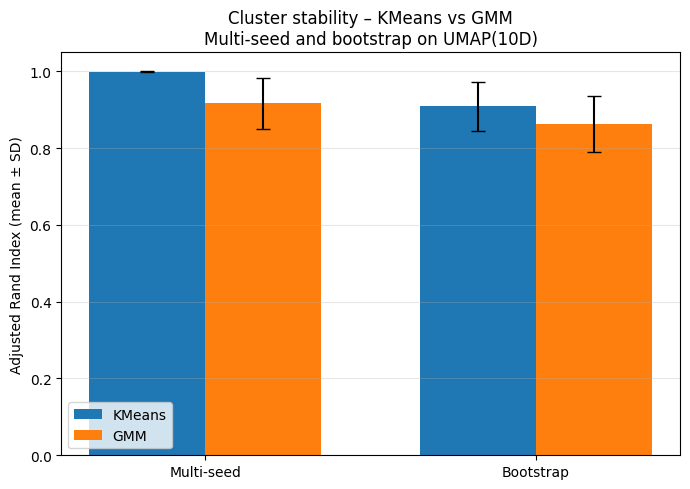

MEANING: nothing random about the way things were extracted, changing the seed comes to similar results. so what about the null hypothesis, that says that the blobs dont do anything by shuffling the maps randomly and seeing how the result are


In [69]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute means and stds ---
mean_km_seed  = kmeans_ari_vals.mean()
std_km_seed   = kmeans_ari_vals.std()
mean_gmm_seed = gmm_ari_vals.mean()
std_gmm_seed  = gmm_ari_vals.std()

mean_km_boot  = kmeans_boot_vals.mean()
std_km_boot   = kmeans_boot_vals.std()
mean_gmm_boot = gmm_boot_vals.mean()
std_gmm_boot  = gmm_boot_vals.std()

print("KMeans  multi-seed  ARI: mean =", mean_km_seed,  "std =", std_km_seed)
print("GMM     multi-seed  ARI: mean =", mean_gmm_seed, "std =", std_gmm_seed)
print("KMeans  bootstrap   ARI: mean =", mean_km_boot,  "std =", std_km_boot)
print("GMM     bootstrap   ARI: mean =", mean_gmm_boot, "std =", std_gmm_boot)

# --- One summary plot: mean ± SD ARI ---
labels = ["Multi-seed", "Bootstrap"]
x = np.arange(len(labels))  # [0, 1]
width = 0.35                # bar width

kmeans_means = [mean_km_seed,  mean_km_boot]
kmeans_stds  = [std_km_seed,   std_km_boot]

gmm_means    = [mean_gmm_seed, mean_gmm_boot]
gmm_stds     = [std_gmm_seed,  std_gmm_boot]

fig, ax = plt.subplots(figsize=(7, 5))

# KMeans bars (left in each group)
ax.bar(
    x - width/2,
    kmeans_means,
    width,
    yerr=kmeans_stds,
    capsize=5,
    label="KMeans",
)

# GMM bars (right in each group)
ax.bar(
    x + width/2,
    gmm_means,
    width,
    yerr=gmm_stds,
    capsize=5,
    label="GMM",
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Adjusted Rand Index (mean ± SD)")
ax.set_title("Cluster stability – KMeans vs GMM\nMulti-seed and bootstrap on UMAP(10D)")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
print("MEANING: nothing random about the way things were extracted, changing the seed comes to similar results. so what about the null hypothesis, that says that the blobs dont do anything by shuffling the maps randomly and seeing how the result are")

Idea (tiny explanation)

Goal:
Test whether the structure in your 10D UMAP + KMeans/GMM is more than you’d expect from “ERSP noise with the same marginal distribution”.

What we do:

Destroy the blob geometry in each ERSP by randomly shuffling its pixels:

Keeps the same global value distribution (same histogram of dB values),

But kills spatial contiguity / blob shapes in time–frequency.

Recompute UMAP(10D) on these shuffled maps.

Re-run KMeans & GMM (K=9) on the null embedding.

Collect:

Silhouette scores for KMeans and GMM on the null data.

ARI between real vs null clusters (for each null run).

Compare:

Real silhouettes vs null silhouette distribution.

ARI(real, null) distribution (should be near 0 if real solution is not what random ERSPs would produce).

If real data gives silhouette >> null and ARI(real, null) ~ 0, you can say your clusters reflect real spatiotemporal structure, not just the value distribution.

Null model: 20 runs, ERSP shape = (129, 300), n_samples = 475
Real KMeans silhouette (K=9): 0.5555
Real GMM    silhouette (K=9): 0.5483

--- Null run 1/20 ---


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  X_null_10d shape: (475, 10)
  KMeans null silhouette: 0.2767, ARI vs real KMeans: 0.0602
  GMM    null silhouette: 0.2419, ARI vs real GMM: 0.0519

--- Null run 2/20 ---


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  X_null_10d shape: (475, 10)
  KMeans null silhouette: 0.2670, ARI vs real KMeans: 0.0609
  GMM    null silhouette: 0.2552, ARI vs real GMM: 0.0590

--- Null run 3/20 ---


...

  X_null_10d shape: (475, 10)
  KMeans null silhouette: 0.2726, ARI vs real KMeans: 0.0623
  GMM    null silhouette: 0.2369, ARI vs real GMM: 0.0519

--- Null run 19/20 ---


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  X_null_10d shape: (475, 10)
  KMeans null silhouette: 0.2668, ARI vs real KMeans: 0.0657
  GMM    null silhouette: 0.2422, ARI vs real GMM: 0.0553

--- Null run 20/20 ---


C:\Users\artoni\.conda\envs\LORA_FLM_env1\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  X_null_10d shape: (475, 10)
  KMeans null silhouette: 0.2581, ARI vs real KMeans: 0.0585
  GMM    null silhouette: 0.2379, ARI vs real GMM: 0.0537

=== Null model summary ===
KMeans real silhouette: 0.5555
KMeans null silhouettes: mean=0.2698, std=0.0063, min=0.2521, max=0.2794
GMM real silhouette: 0.5483
GMM null silhouettes: mean=0.2457, std=0.0085, min=0.2359, max=0.2646
KMeans ARI(real vs null): mean=0.0617, std=0.0035, min=0.0524, max=0.0681
GMM ARI(real vs null): mean=0.0529, std=0.0030, min=0.0482, max=0.0600


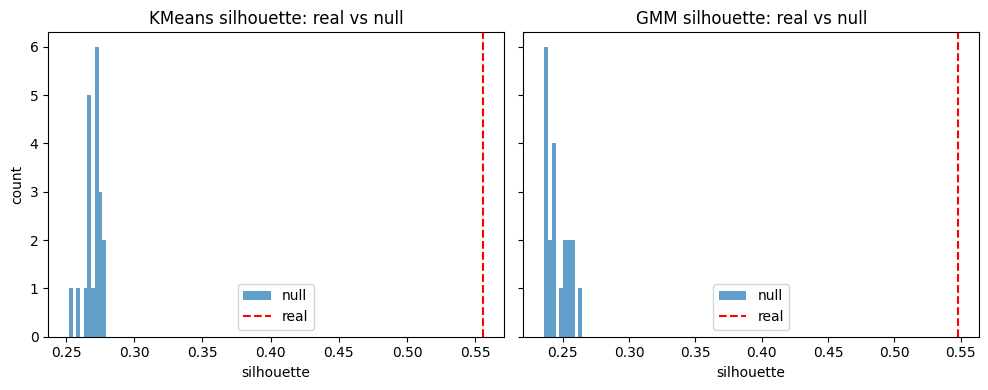

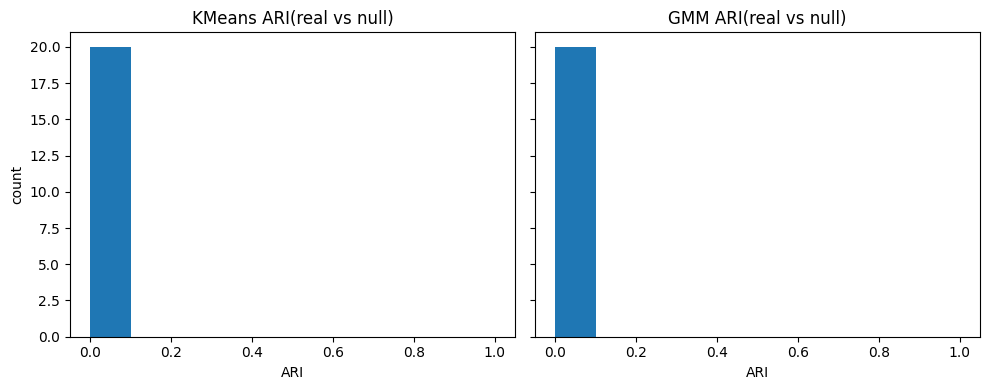

In [70]:
import numpy as np
import umap
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

N_NULL_RUNS = 20  # number of null datasets (increase later if needed)
N_FREQ, N_TIME = ersp_list[0].shape

print(f"Null model: {N_NULL_RUNS} runs, ERSP shape = ({N_FREQ}, {N_TIME}), "
      f"n_samples = {len(ersp_list)}")

# Sanity: real silhouette for reference (in 10D space you already have)
real_kmeans_sil = silhouette_score(X_for_clustering, best_kmeans_labels)
real_gmm_sil    = silhouette_score(X_for_clustering, best_gmm_labels)
print(f"Real KMeans silhouette (K={best_K_kmeans}): {real_kmeans_sil:.4f}")
print(f"Real GMM    silhouette (K={best_K_gmm}): {real_gmm_sil:.4f}")

# ============================================================
# Helper: shuffle a single ERSP array
# ============================================================

def shuffle_ersp_array(arr, rng):
    """
    arr: 2D array (N_FREQ, N_TIME)
    rng: np.random.Generator
    Returns a new array with the same values but randomly permuted positions.
    This destroys blob geometry but preserves the marginal distribution.
    """
    flat = arr.reshape(-1).copy()
    rng.shuffle(flat)
    return flat.reshape(arr.shape)


# ============================================================
# Main null loop
# ============================================================

kmeans_sil_null = []
gmm_sil_null = []
kmeans_ari_null_vs_real = []
gmm_ari_null_vs_real = []

for run in range(N_NULL_RUNS):
    print(f"\n--- Null run {run+1}/{N_NULL_RUNS} ---")
    rng = np.random.default_rng(RANDOM_STATE + 5000 + run)

    # 1) Build shuffled ERSP list
    ersp_list_null = [shuffle_ersp_array(arr, rng) for arr in ersp_list]

    # 2) Flatten null ERSPs -> big feature matrix (F*T)
    X_null_flat = np.empty((len(ersp_list_null), N_FREQ * N_TIME), dtype=np.float32)
    for i, arr in enumerate(ersp_list_null):
        X_null_flat[i, :] = arr.reshape(-1)

    # 3) UMAP(10D) on null maps, same params as real
    reducer_null = umap.UMAP(
        n_neighbors=30,
        min_dist=0.05,
        n_components=10,
        metric="euclidean",
        random_state=RANDOM_STATE + 6000 + run,
    )
    X_null_10d = reducer_null.fit_transform(X_null_flat)
    print("  X_null_10d shape:", X_null_10d.shape)

    # 4) KMeans on null
    km_null = KMeans(
        n_clusters=best_K_kmeans,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=RANDOM_STATE + 7000 + run,
        verbose=0,
    )
    km_null.fit(X_null_10d)
    labels_null_km = km_null.labels_

    sil_km = silhouette_score(X_null_10d, labels_null_km)
    kmeans_sil_null.append(sil_km)

    # compare to REAL KMeans clustering on REAL data (same sample indices)
    ari_km = adjusted_rand_score(best_kmeans_labels, labels_null_km)
    kmeans_ari_null_vs_real.append(ari_km)

    print(f"  KMeans null silhouette: {sil_km:.4f}, ARI vs real KMeans: {ari_km:.4f}")

    # 5) GMM on null
    gmm_null = GaussianMixture(
        n_components=best_K_gmm,
        covariance_type="diag",
        random_state=RANDOM_STATE + 8000 + run,
        n_init=5,
        max_iter=300,
    )
    gmm_null.fit(X_null_10d)
    labels_null_gmm = gmm_null.predict(X_null_10d)

    sil_gmm = silhouette_score(X_null_10d, labels_null_gmm)
    gmm_sil_null.append(sil_gmm)

    ari_gmm = adjusted_rand_score(best_gmm_labels, labels_null_gmm)
    gmm_ari_null_vs_real.append(ari_gmm)

    print(f"  GMM    null silhouette: {sil_gmm:.4f}, ARI vs real GMM: {ari_gmm:.4f}")

kmeans_sil_null = np.array(kmeans_sil_null)
gmm_sil_null    = np.array(gmm_sil_null)
kmeans_ari_null_vs_real = np.array(kmeans_ari_null_vs_real)
gmm_ari_null_vs_real    = np.array(gmm_ari_null_vs_real)

# ============================================================
# Summary + quick plots
# ============================================================

print("\n=== Null model summary ===")

print(f"KMeans real silhouette: {real_kmeans_sil:.4f}")
print(f"KMeans null silhouettes: mean={kmeans_sil_null.mean():.4f}, "
      f"std={kmeans_sil_null.std():.4f}, "
      f"min={kmeans_sil_null.min():.4f}, max={kmeans_sil_null.max():.4f}")

print(f"GMM real silhouette: {real_gmm_sil:.4f}")
print(f"GMM null silhouettes: mean={gmm_sil_null.mean():.4f}, "
      f"std={gmm_sil_null.std():.4f}, "
      f"min={gmm_sil_null.min():.4f}, max={gmm_sil_null.max():.4f}")

print(f"KMeans ARI(real vs null): mean={kmeans_ari_null_vs_real.mean():.4f}, "
      f"std={kmeans_ari_null_vs_real.std():.4f}, "
      f"min={kmeans_ari_null_vs_real.min():.4f}, max={kmeans_ari_null_vs_real.max():.4f}")

print(f"GMM ARI(real vs null): mean={gmm_ari_null_vs_real.mean():.4f}, "
      f"std={gmm_ari_null_vs_real.std():.4f}, "
      f"min={gmm_ari_null_vs_real.min():.4f}, max={gmm_ari_null_vs_real.max():.4f}")

# --- Silhouette comparison plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# KMeans
axes[0].hist(kmeans_sil_null, bins=10, alpha=0.7, label="null")
axes[0].axvline(real_kmeans_sil, color="red", linestyle="--", label="real")
axes[0].set_title("KMeans silhouette: real vs null")
axes[0].set_xlabel("silhouette")
axes[0].set_ylabel("count")
axes[0].legend()

# GMM
axes[1].hist(gmm_sil_null, bins=10, alpha=0.7, label="null")
axes[1].axvline(real_gmm_sil, color="red", linestyle="--", label="real")
axes[1].set_title("GMM silhouette: real vs null")
axes[1].set_xlabel("silhouette")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- ARI(real vs null) plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(kmeans_ari_null_vs_real, bins=10, range=(0, 1))
axes[0].set_title("KMeans ARI(real vs null)")
axes[0].set_xlabel("ARI")
axes[0].set_ylabel("count")

axes[1].hist(gmm_ari_null_vs_real, bins=10, range=(0, 1))
axes[1].set_title("GMM ARI(real vs null)")
axes[1].set_xlabel("ARI")

plt.tight_layout()
plt.show()


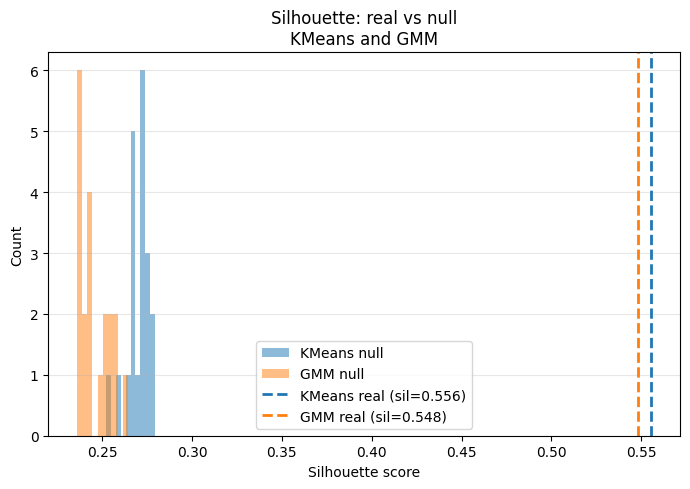

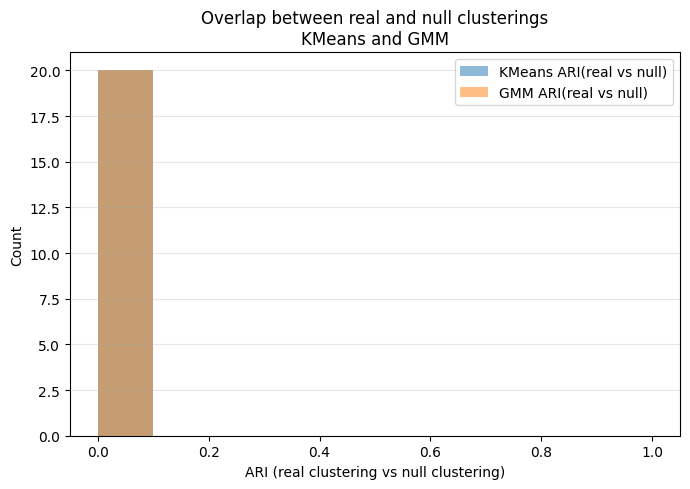

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1) Silhouette: real vs null in the SAME plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

bins = 10

# Null histograms (slightly transparent)
ax.hist(
    kmeans_sil_null,
    bins=bins,
    alpha=0.5,
    label="KMeans null",
)
ax.hist(
    gmm_sil_null,
    bins=bins,
    alpha=0.5,
    label="GMM null",
)

# Real silhouettes as vertical lines
ax.axvline(real_kmeans_sil, color="C0", linestyle="--", linewidth=2,
           label=f"KMeans real (sil={real_kmeans_sil:.3f})")
ax.axvline(real_gmm_sil,    color="C1", linestyle="--", linewidth=2,
           label=f"GMM real (sil={real_gmm_sil:.3f})")

ax.set_xlabel("Silhouette score")
ax.set_ylabel("Count")
ax.set_title("Silhouette: real vs null\nKMeans and GMM")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2) ARI(real vs null): both algos on one plot
#     (how similar are null clusterings to the real ones)
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

bins = np.linspace(0, 1, 11)

ax.hist(
    kmeans_ari_null_vs_real,
    bins=bins,
    alpha=0.5,
    label="KMeans ARI(real vs null)",
)
ax.hist(
    gmm_ari_null_vs_real,
    bins=bins,
    alpha=0.5,
    label="GMM ARI(real vs null)",
)

ax.set_xlabel("ARI (real clustering vs null clustering)")
ax.set_ylabel("Count")
ax.set_title("Overlap between real and null clusterings\nKMeans and GMM")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [78]:
import numpy as np

def summarize_real_vs_null(real_value, null_values, label):
    null_values = np.asarray(null_values)
    mean_null = np.nanmean(null_values)
    std_null  = np.nanstd(null_values)

    # z-score (how many stds above/below null mean)
    if std_null > 0:
        z = (real_value - mean_null) / std_null
    else:
        z = np.nan

    # empirical p-value: how often does null >= real?
    # (for silhouette & ARI where larger = better)
    p_emp = np.mean(null_values >= real_value)

    print(f"\n=== {label} ===")
    print(f"Real value          : {real_value:.4f}")
    print(f"Null mean ± SD      : {mean_null:.4f} ± {std_null:.4f}")
    print(f"Z-score (real vs null mean): {z:.2f}")
    print(f"Empirical p (null ≥ real)  : {p_emp:.4f}")

# --- silhouettes ---
summarize_real_vs_null(real_kmeans_sil, kmeans_sil_null, "KMeans silhouette")
summarize_real_vs_null(real_gmm_sil,    gmm_sil_null,    "GMM silhouette")

# --- ARI (real vs null) ---
# here, "real" reference is 0 (if clusters were unrelated, ARI≈0),
# and the null distribution is ARI(real vs null) you already computed.
# We actually want to see if ARI is *close to 0*, so we can also
# look at |ARI| compared to distribution.
summarize_real_vs_null(
    0.0, np.abs(kmeans_ari_null_vs_real), "KMeans |ARI(real vs null)| (expect small)"
)
summarize_real_vs_null(
    0.0, np.abs(gmm_ari_null_vs_real), "GMM |ARI(real vs null)| (expect small)"
)



=== KMeans silhouette ===
Real value          : 0.5555
Null mean ± SD      : 0.2698 ± 0.0063
Z-score (real vs null mean): 45.69
Empirical p (null ≥ real)  : 0.0000

=== GMM silhouette ===
Real value          : 0.5483
Null mean ± SD      : 0.2457 ± 0.0085
Z-score (real vs null mean): 35.67
Empirical p (null ≥ real)  : 0.0000

=== KMeans |ARI(real vs null)| (expect small) ===
Real value          : 0.0000
Null mean ± SD      : 0.0617 ± 0.0035
Z-score (real vs null mean): -17.61
Empirical p (null ≥ real)  : 1.0000

=== GMM |ARI(real vs null)| (expect small) ===
Real value          : 0.0000
Null mean ± SD      : 0.0529 ± 0.0030
Z-score (real vs null mean): -17.61
Empirical p (null ≥ real)  : 1.0000


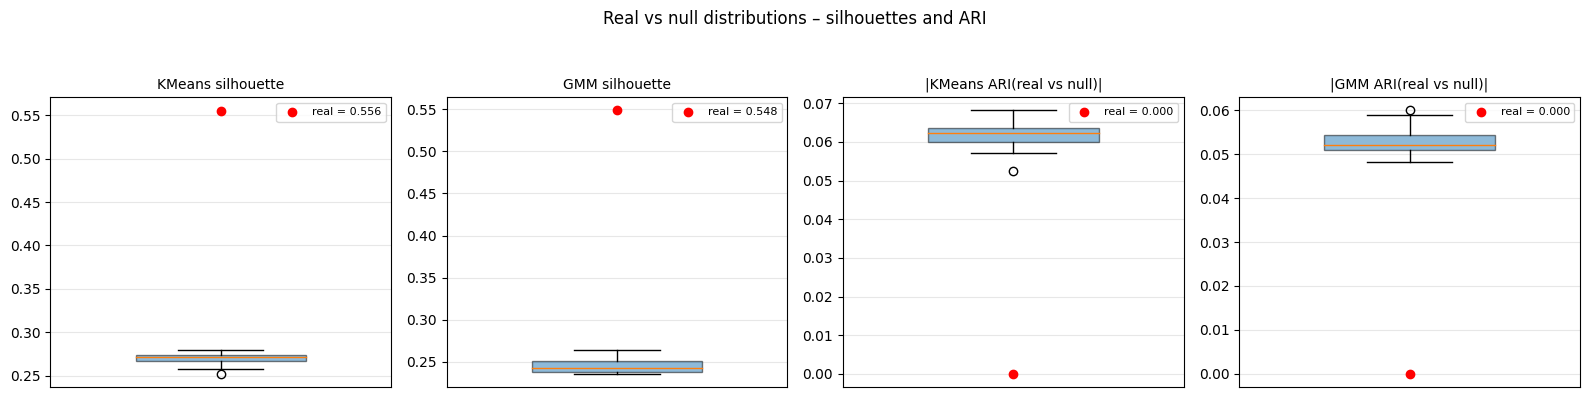

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Collect metrics in a compact structure
metrics = [
    ("KMeans silhouette", real_kmeans_sil, kmeans_sil_null),
    ("GMM silhouette",    real_gmm_sil,    gmm_sil_null),
    ("|KMeans ARI(real vs null)|", 0.0, np.abs(kmeans_ari_null_vs_real)),
    ("|GMM ARI(real vs null)|",    0.0, np.abs(gmm_ari_null_vs_real)),
]

n_metrics = len(metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 4), sharey=False)

if n_metrics == 1:
    axes = [axes]

for ax, (title, real_val, null_vals) in zip(axes, metrics):
    null_vals = np.asarray(null_vals)

    # Boxplot for null
    bp = ax.boxplot(
        null_vals,
        positions=[0],
        widths=0.5,
        showfliers=True,
        patch_artist=True,
    )
    for patch in bp['boxes']:
        patch.set_alpha(0.5)

    # Real value as a dot
    ax.scatter(
        [0],
        [real_val],
        color="red",
        zorder=3,
        label=f"real = {real_val:.3f}",
    )

    ax.set_xticks([])
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, loc="best")

plt.suptitle("Real vs null distributions – silhouettes and ARI", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


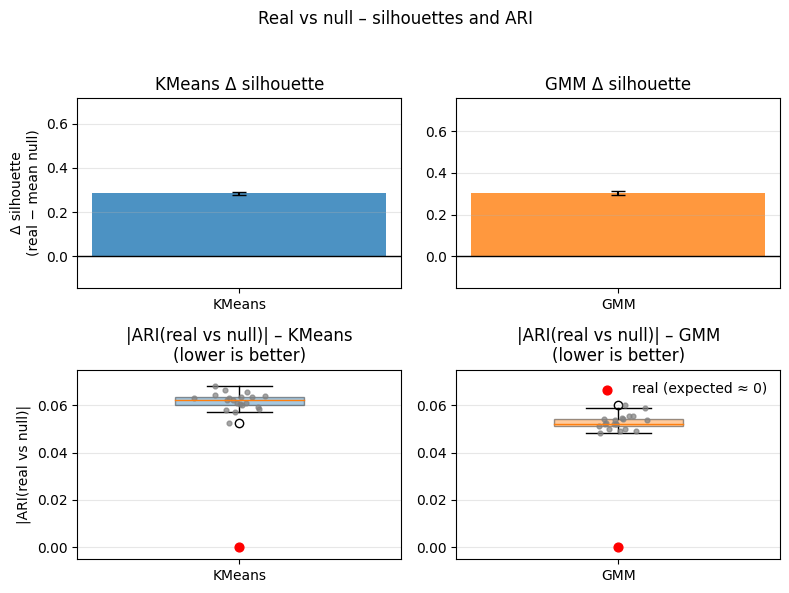

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# --- Make sure these exist from previous steps ---
# real_kmeans_sil, real_gmm_sil
# kmeans_sil_null, gmm_sil_null
# kmeans_ari_null_vs_real, gmm_ari_null_vs_real

km_null_sil = np.asarray(kmeans_sil_null)
gm_null_sil = np.asarray(gmm_sil_null)

km_null_ari = np.abs(np.asarray(kmeans_ari_null_vs_real))
gm_null_ari = np.abs(np.asarray(gmm_ari_null_vs_real))

# --- Δ silhouette stats ---
km_sil_mean = km_null_sil.mean()
km_sil_std  = km_null_sil.std(ddof=1)
gm_sil_mean = gm_null_sil.mean()
gm_sil_std  = gm_null_sil.std(ddof=1)

km_delta = real_kmeans_sil - km_sil_mean
gm_delta = real_gmm_sil    - gm_sil_mean

# --- Figure ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
(ax11, ax12), (ax21, ax22) = axes

# ======================================================
# Top row: Δ silhouette (real - mean(null))
# ======================================================

# KMeans
ax11.bar(
    [0],
    [km_delta],
    yerr=[km_sil_std],
    capsize=5,
    color="C0",
    alpha=0.8,
)
ax11.axhline(0, color="k", linewidth=1)
ax11.set_xticks([0])
ax11.set_xticklabels(["KMeans"])
ax11.set_ylabel("Δ silhouette\n(real − mean null)")
ax11.set_title("KMeans Δ silhouette")
ax11.grid(axis="y", alpha=0.3)

# GMM
ax12.bar(
    [0],
    [gm_delta],
    yerr=[gm_sil_std],
    capsize=5,
    color="C1",
    alpha=0.8,
)
ax12.axhline(0, color="k", linewidth=1)
ax12.set_xticks([0])
ax12.set_xticklabels(["GMM"])
ax12.set_title("GMM Δ silhouette")
ax12.grid(axis="y", alpha=0.3)

# Tight y-lims around bars
for ax, delta in zip([ax11, ax12], [km_delta, gm_delta]):
    span = max(abs(delta) * 1.5, 0.05)
    ax.set_ylim(delta - span, delta + span)

# ======================================================
# Bottom row: |ARI(real vs null)| (lower is better)
# ======================================================

# KMeans ARI
bp_km = ax21.boxplot(
    km_null_ari,
    positions=[0],
    widths=0.4,
    showfliers=True,
    patch_artist=True,
)
for box in bp_km["boxes"]:
    box.set_facecolor("C0")
    box.set_alpha(0.4)

# jittered null points
rng = np.random.default_rng(0)
x_jitter = 0 + 0.06 * rng.normal(size=km_null_ari.shape[0])
ax21.scatter(
    x_jitter,
    km_null_ari,
    color="gray",
    s=12,
    alpha=0.7,
    zorder=2,
)

# real ARI (0) as red dot
ax21.scatter(
    0,
    0.0,
    color="red",
    s=40,
    zorder=3,
    label="real (expected ≈ 0)",
)
ax21.set_xticks([0])
ax21.set_xticklabels(["KMeans"])
ax21.set_ylabel(r"|ARI(real vs null)|")
ax21.set_title("|ARI(real vs null)| – KMeans\n(lower is better)")
ax21.grid(axis="y", alpha=0.3)

# GMM ARI
bp_gm = ax22.boxplot(
    gm_null_ari,
    positions=[0],
    widths=0.4,
    showfliers=True,
    patch_artist=True,
)
for box in bp_gm["boxes"]:
    box.set_facecolor("C1")
    box.set_alpha(0.4)

x_jitter = 0 + 0.06 * rng.normal(size=gm_null_ari.shape[0])
ax22.scatter(
    x_jitter,
    gm_null_ari,
    color="gray",
    s=12,
    alpha=0.7,
    zorder=2,
)

ax22.scatter(
    0,
    0.0,
    color="red",
    s=40,
    zorder=3,
    label="real (expected ≈ 0)",
)
ax22.set_xticks([0])
ax22.set_xticklabels(["GMM"])
ax22.set_title("|ARI(real vs null)| – GMM\n(lower is better)")
ax22.grid(axis="y", alpha=0.3)

# Match y-lims for ARI panels
ari_max = max(km_null_ari.max(), gm_null_ari.max()) * 1.1
ax21.set_ylim(-0.005, ari_max)
ax22.set_ylim(-0.005, ari_max)

# Shared legend for ARI panels
handles, labels_ = ax21.get_legend_handles_labels()
ax22.legend(handles, labels_, frameon=False, loc="upper right")

fig.suptitle("Real vs null – silhouettes and ARI", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


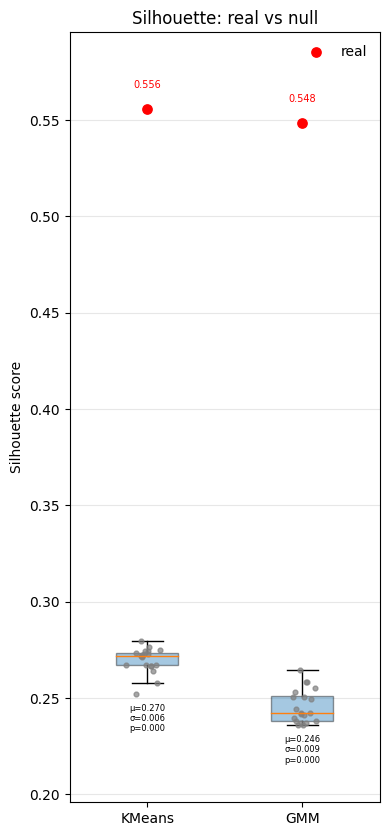

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure these are numpy arrays
km_null = np.asarray(kmeans_sil_null)
gm_null = np.asarray(gmm_sil_null)

labels     = ["KMeans", "GMM"]
null_sets  = [km_null, gm_null]
real_vals  = [real_kmeans_sil, real_gmm_sil]

fig, ax = plt.subplots(figsize=(4, 10))

# -------------------------
# Boxplots for null values
# -------------------------
bp = ax.boxplot(
    null_sets,
    positions=np.arange(len(labels)),
    widths=0.4,
    showmeans=False,
    showfliers=False,
    patch_artist=True,
)

for box in bp["boxes"]:
    box.set_alpha(0.4)

# -------------------------
# Jittered null points
# -------------------------
rng = np.random.default_rng(0)
for i, null_vals in enumerate(null_sets):
    x_jitter = i + 0.06 * rng.normal(size=null_vals.shape[0])
    ax.scatter(
        x_jitter,
        null_vals,
        color="gray",
        s=12,
        alpha=0.7,
        zorder=2,
    )

# -------------------------
# Real values as red dots
# + small text label
# -------------------------
for i, rv in enumerate(real_vals):
    ax.scatter(
        i,
        rv,
        color="red",
        s=45,
        zorder=3,
        label="real" if i == 0 else None,
    )
    ax.text(
        i,
        rv + 0.01,
        f"{rv:.3f}",
        ha="center",
        va="bottom",
        fontsize=7,
        color="red",
    )

# -------------------------
# Optional: annotate null mean/std and empirical p
# p = fraction of null >= real (one-sided, “is real better?”)
# -------------------------
for i, (label, null_vals, rv) in enumerate(zip(labels, null_sets, real_vals)):
    mean_null = null_vals.mean()
    std_null  = null_vals.std(ddof=1)
    p_emp     = (null_vals >= rv).mean()

    ax.text(
        i,
        null_vals.min() - 0.005,
        f"μ={mean_null:.3f}\nσ={std_null:.3f}\np={p_emp:.3f}",
        ha="center",
        va="top",
        fontsize=6,
    )

# Axes formatting
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette: real vs null")

# Keep y-range tight but not crazy
y_min = min(km_null.min(), gm_null.min()) - 0.04
y_max = max(real_vals) + 0.04
ax.set_ylim(y_min, y_max)

ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)


C:\Users\artoni\AppData\Local\Temp\ipykernel_6784\1300978290.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


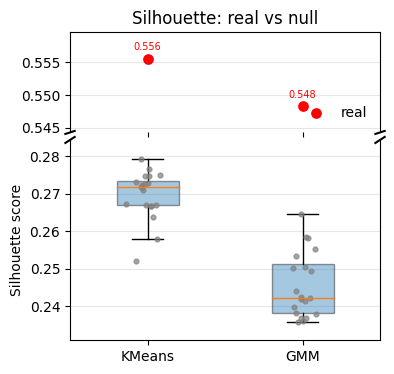

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Data
km_null = np.asarray(kmeans_sil_null)
gm_null = np.asarray(gmm_sil_null)

labels    = ["KMeans", "GMM"]
null_sets = [km_null, gm_null]
real_vals = [real_kmeans_sil, real_gmm_sil]

positions = np.arange(len(labels))

# -------------------------------------------------
# Two stacked axes sharing x: TOP = real, BOTTOM = null
# -------------------------------------------------
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(4, 4),
    gridspec_kw={"height_ratios": [1, 2], "hspace": 0.05},
)

# -----------------------------
# Bottom axis: null (box + jitter)
# -----------------------------
bp = ax_bottom.boxplot(
    null_sets,
    positions=positions,
    widths=0.4,
    showmeans=False,
    showfliers=False,
    patch_artist=True,
)

for box in bp["boxes"]:
    box.set_alpha(0.4)

rng = np.random.default_rng(0)
for i, null_vals in enumerate(null_sets):
    x_jitter = i + 0.06 * rng.normal(size=null_vals.shape[0])
    ax_bottom.scatter(
        x_jitter,
        null_vals,
        color="gray",
        s=12,
        alpha=0.7,
        zorder=2,
    )

# Y-limits for null region
null_min = min(km_null.min(), gm_null.min()) - 0.005
null_max = max(km_null.max(), gm_null.max()) + 0.005
ax_bottom.set_ylim(null_min, null_max)

# -----------------------------
# Top axis: real silhouettes only
# -----------------------------
for i, rv in enumerate(real_vals):
    ax_top.scatter(
        positions[i],
        rv,
        color="red",
        s=45,
        zorder=3,
        label="real" if i == 0 else None,
    )
    ax_top.text(
        positions[i],
        rv + 0.001,
        f"{rv:.3f}",
        ha="center",
        va="bottom",
        fontsize=7,
        color="red",
    )

real_min = min(real_vals) - 0.004
real_max = max(real_vals) + 0.007
ax_top.set_ylim(real_min, real_max)

# -----------------------------
# Broken-axis cosmetics
# -----------------------------
# Hide touching spines
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)

ax_top.tick_params(labelbottom=False)  # no x labels on top
ax_bottom.xaxis.tick_bottom()

# Diagonal break marks
d = 0.015
kwargs_top = dict(transform=ax_top.transAxes, color="k", clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs_top)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs_top)

kwargs_bot = dict(transform=ax_bottom.transAxes, color="k", clip_on=False)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs_bot)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs_bot)

# Labels / title
ax_bottom.set_xticks(positions)
ax_bottom.set_xticklabels(labels)
ax_bottom.set_ylabel("Silhouette score")
ax_top.set_title("Silhouette: real vs null")

ax_bottom.grid(axis="y", alpha=0.3)
ax_top.grid(axis="y",   alpha=0.3)
ax_top.legend(frameon=True, loc="lower right")

plt.tight_layout()
plt.show()


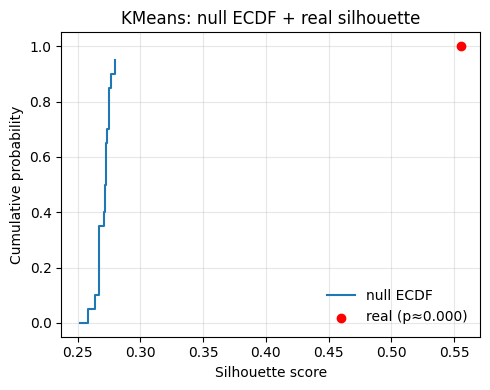

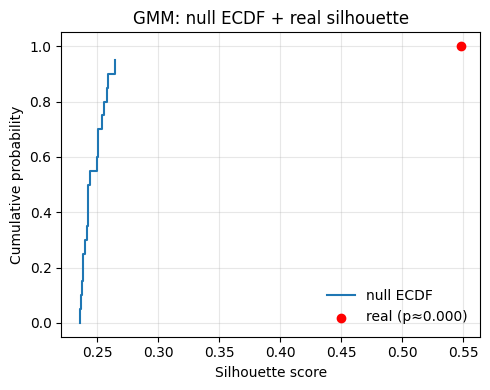

In [80]:
def plot_ecdf_with_real(null_vals, real_val, title):
    null_vals = np.sort(np.asarray(null_vals))
    n = len(null_vals)
    y = np.linspace(0, 1, n, endpoint=False)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.step(null_vals, y, where="post", label="null ECDF")

    # Real value
    # empirical percentile = fraction of null <= real
    perc = (null_vals <= real_val).mean()

    ax.scatter(
        [real_val], [perc],
        color="red",
        zorder=3,
        label=f"real (p≈{1-perc:.3f})",
    )

    ax.set_xlabel("Silhouette score")
    ax.set_ylabel("Cumulative probability")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.show()

# KMeans
plot_ecdf_with_real(
    kmeans_sil_null,
    real_kmeans_sil,
    "KMeans: null ECDF + real silhouette"
)

# GMM
plot_ecdf_with_real(
    gmm_sil_null,
    real_gmm_sil,
    "GMM: null ECDF + real silhouette"
)


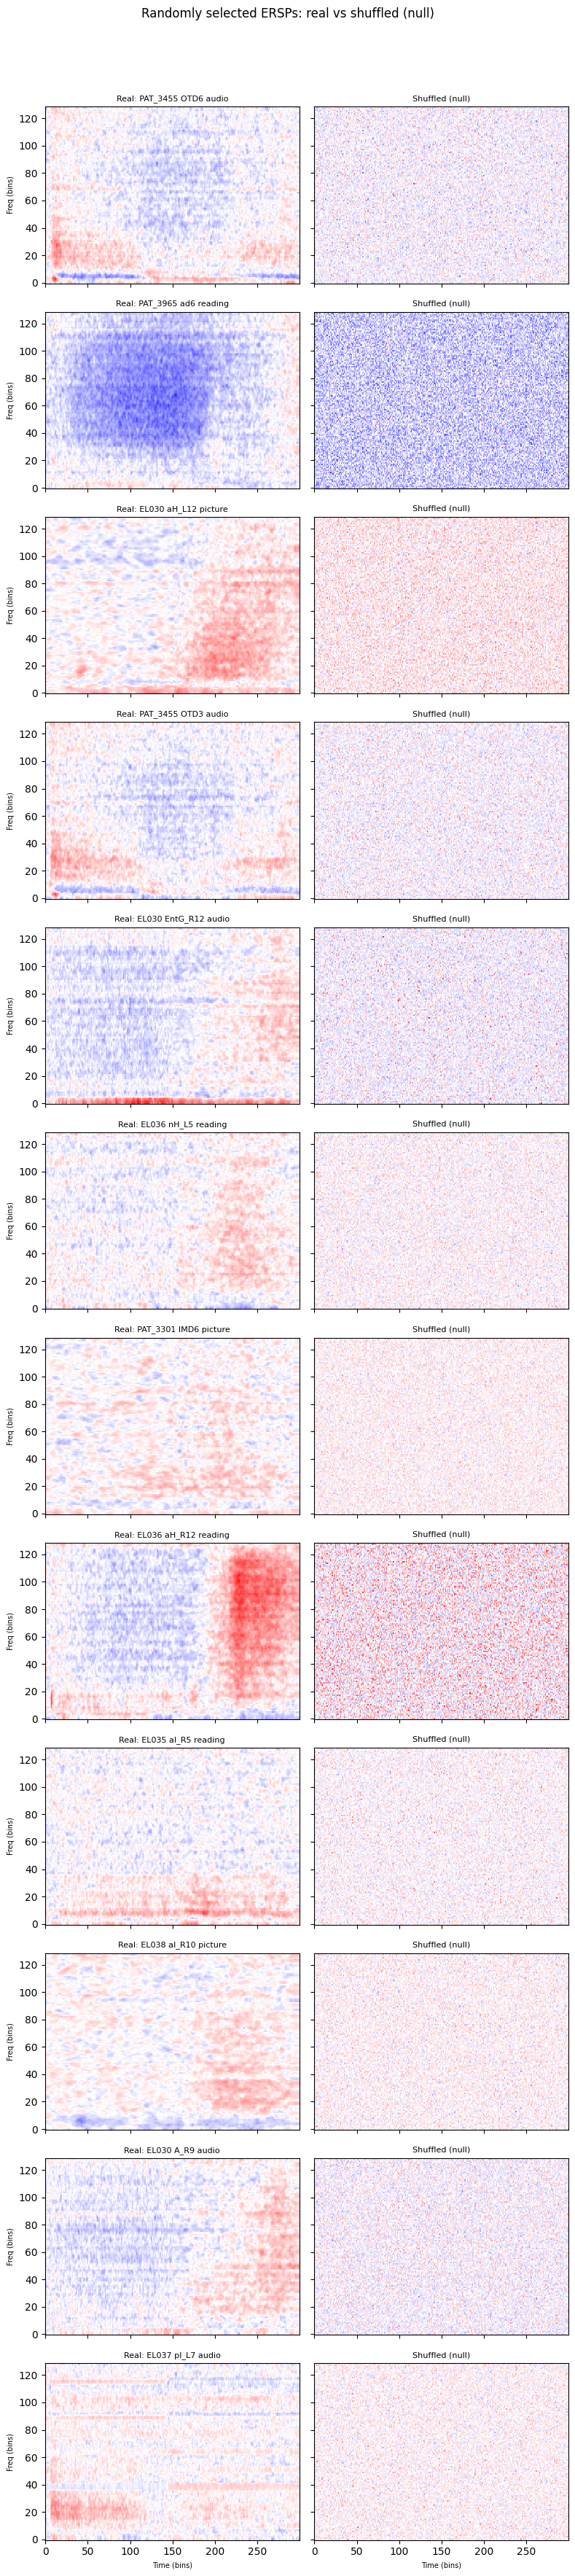

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# How many electrodes to show
N_EXAMPLES = 12   # adjust if you want more/less

rng = np.random.default_rng(RANDOM_STATE + 9000)

# Random unique electrode indices
indices = rng.choice(len(ersp_list), size=min(N_EXAMPLES, len(ersp_list)), replace=False)

# Compute a symmetric color scale from the selected REAL ERSPs
vals = []
for idx in indices:
    arr = ersp_list[idx]
    vals.append(arr.ravel())
vals = np.concatenate(vals)
v = np.nanmax(np.abs(vals))
vmin, vmax = -v, v  # or fix to -5, 5 if you prefer

n_rows = len(indices)
fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(8, 3 * n_rows),
    sharex=True,
    sharey=True
)

# Ensure axes is 2D array even if n_rows == 1
if n_rows == 1:
    axes = np.array([axes])

for row, idx in enumerate(indices):
    real = ersp_list[idx]
    shuffled = shuffle_ersp_array(real, rng)

    ax_real = axes[row, 0]
    ax_null = axes[row, 1]

    im0 = ax_real.imshow(
        real,
        origin="lower",
        aspect="auto",
        cmap="bwr",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )
    ax_real.set_ylabel("Freq (bins)", fontsize=7)

    im1 = ax_null.imshow(
        shuffled,
        origin="lower",
        aspect="auto",
        cmap="bwr",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    meta = df_meta.iloc[idx]
    ax_real.set_title(
        f"Real: {meta['patient_id']} {meta['electrode']} {meta['condition']}",
        fontsize=8
    )
    ax_null.set_title("Shuffled (null)", fontsize=8)

# X labels only on bottom row
for ax in axes[-1, :]:
    ax.set_xlabel("Time (bins)", fontsize=7)

fig.suptitle(
    "Randomly selected ERSPs: real vs shuffled (null)",
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
